[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/prodh004/LIMEM/blob/main/LIMEM.ipynb)

# <center> <font color='blue'> **Learning Lake Ice Phenology and Freeze-Thaw Dynamics using L-band Radiometry: Insights from SMAP Satellite Observations** <center>

#### <center> <font color='balck'> Md Mehedi Hasan Prodhan, Ardeshir Ebtehaj <center>
#### <center> Saint Anthony Falls Laboratory, Department of Civil Environmental and Geo- Engineering,
#### <center> University of Minnesota <center>
#### <center> Date: April, 2026 (rev 01)

---
<div align="justify"> This notebook presents two complementary components for lake ice monitoring using SMAP L-band passive microwave observations over Great Bear Lake, Canada. First, a non-parametric binary segmentation algorithm with a radial basis function (RBF) kernel is applied to smoothed dual-polarized TB time series to detect four seasonal phenological breakpoints — melt start, ice-off, freeze start, and ice-on — which are subsequently refined using local extrema anchoring and Mann-Whitney U statistical testing. The detected breakpoints further delineate three sub-stages within the melt period: an initial TB hump (M1), a plateau phase (M2), and a sharp TB decline (M3). Second, a sequential detection–estimation framework is developed to simulate annual dual-polarized TB time series. A supervised XGBoost classifier trained on a 5-day rolling window of H- and V-polarization TB observations from 2017–2024 (excluding 2019 due to extended data gaps) identifies six phenological states at daily resolution and is evaluated on the withheld 2016 test year. State-specific forward models then simulate TBs sequentially based on the detected state, retrieving water–ice interface roughness during the frozen period, snow and ice wetness during melt phases, fractional ice cover during late melt and freeze-up, and open-water roughness during the ice-free season.
</br>
</br>
This notebook is organized as follows. Section 1, describes the data including the Soil Moisture Active Passive (SMAP) products as well as the ERA5 reanalysis data from the European Centre for Medium-Range Weather Forecasts (ECMWF). Section 2 describes the methodolgy, and the last section provides an example for TB retrieval using the proposed algorithm.</div>

# **1. Data**

## **1.1** **Data Description**

<span style="color:green;"><b><i>1.1.1 Satellite and Reanalysis Input Data</i></b></span>

Brightness temperatures (TBs) from the [SMAP](https://smap.jpl.nasa.gov/) (Soil Moisture Active Passive) L-band radiometer, at both H and V polarizations, are used as the primary observational input. A set of hourly [ERA5](https://www.ecmwf.int/en/forecasts/datasets/reanalysis-datasets/era5) reanalysis products at ~9 km resolution provides the thermodynamic state variables: lake mixed-layer temperature (`lmlt`), lake ice surface temperature (`lict`), lake ice depth (`licd`), and 2-metre air temperature (`t2m`). Snow depth over lake ice is sourced from [The State and Fate of Lake Ice Thickness in the Northern Hemisphere](https://doi.org/10.5194/tc-2022-42).


***SMAP TBs***
*   L-band brightness temperatures at H and V polarizations (1.41 GHz)

***ERA5 Land Variables***
*   `lmlt` = Lake Mixed-Layer Temperature ($\rm K$)
*   `lict` = Lake Ice Surface Temperature ($\rm K$)
*   `licd` = Lake Ice Depth ($\rm m$)
*   `t2m` = 2m Air Temperature ($\rm K$)

***Snow Depth***
*   `sd` = Snow Depth over Lake Ice ($\rm m$) — sourced from [The State and Fate of Lake Ice Thickness in the Northern Hemisphere](https://doi.org/10.5194/tc-2022-42)

## **1.2 Database Organization and Loading**

**Inputs for the Lake Ice Phenology detection are as follows:**
> **Inputs:**

*   $\text{TBs} = X\in\mathbb{R}^{2\times365}$ (Smoothed uncorrected Brightness Temperature at both pols [K])

> **Outputs:**

*   Output of the lake ice phenology detection algorithm is a vector containing the days of phenology change.

**For the XGBoost based detection-estimation, the inputs and outputs are as follows:**

**Detection step:**
> **Inputs:**

*  $\text{TBs} = X\in\mathbb{R}^{2\times5}$ (SMAP Brightness Temperature at both pols [K])

> **Outputs:**

*   Output is the state of the lake (Frozen, early-melt, mid-melt, late-melt, open water, or freezing).

**Estimation step:**
> **Inputs:**

*    `lmlt` = Lake mixed layer temperature [K]
*    `lict` = Lake ice temperature [K]
*    `licd` = Lake ice thickness [m]
*    `t2m` = 2-m air temperature [K]
*    `sd` = Climatological snow depth [m]

> **Outputs**:

*   Output of the estimation algorithm is a vector containing TB at h-pol and v-pol [K], respectively.

## **1.3 Code**
To run this notebook on Google Colab, you need to clone this repository

In [1]:
# Clone the repo
import os
# !git clone https://https://github.com/prodh004/LIMEM.git
# os.chdir("LIMEM")

In [54]:
import numpy as np, pandas as pd, pickle, matplotlib.pyplot as plt, matplotlib as mpl, matplotlib.lines as mlines, matplotlib.patches as mpatches
from tqdm import tqdm
from typing import Union
from scipy.optimize import least_squares
from LakeIceEmit import LakeIceEmit
from DielecModels import EpsWater_Double
from MWPropEquations import InterfaceRefl
from scipy.stats import mannwhitneyu
from ruptures.costs import CostRbf
import ruptures as rpt
from scipy.signal import savgol_filter
from mpl_toolkits.basemap import Basemap
import matplotlib.gridspec as gridspec
from matplotlib.ticker import AutoMinorLocator
from matplotlib.ticker import MaxNLocator
import warnings
from matplotlib.colors import ListedColormap, BoundaryNorm
from sklearn.metrics import classification_report, confusion_matrix, f1_score, balanced_accuracy_score, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
from scipy.optimize import minimize, LinearConstraint
import matplotlib.dates as mdates
import datetime
from matplotlib.ticker import ScalarFormatter
from scipy.interpolate import UnivariateSpline

warnings.filterwarnings("ignore", message=".*pcolormesh.*")
warnings.filterwarnings("ignore", message="delta_grad == 0.0")

In [3]:
polar_lat = np.load(r"Demo data\SMAP\Master_polar_lat.npy")
polar_lon = np.load(r"Demo data\SMAP\Master_polar_lon.npy")

In [4]:
with open('Demo data\\SMAP\\demo_data_gbl.pkl', 'rb') as f:
    polar_lake_data = pickle.load(f)
len(polar_lake_data)

346

In [5]:
gbl_polar = []
for i in polar_lake_data:
    if i['Name'] == 'Great Bear' and i['Water fraction'] >= 0.5:
        gbl_polar.append(i)
len(gbl_polar)

346

# **2.  Methodology**
## 2.1. Lake ice phenology detection
The lake ice phenology detection algorithm identifies four seasonal breakpoints — melt start, ice-off, freeze start, and ice-on — through a three-stage refinement pipeline applied to dual-polarization L-band TBs. First, binary segmentation (`ruptures.Binseg`) with an RBF kernel (`gamma=0.01`) is applied to the combined smoothed H and V polarization TB signal to locate approximate change points. These are then anchored to physically meaningful local extrema in the raw TB time series. Finally, the breakpoints are refined using the Mann-Whitney U test, scanning forward or backward from each candidate until a statistically significant shift is confirmed in both polarizations simultaneously.

<div align="center">
  <img src="https://raw.githubusercontent.com/prodh004/LIMEM/main/Figure/Fig_01.jpeg" alt="Water-Ice-Snow-Air continuum Schematic" width="600"/></br>
  <em>
    <strong>Figure 1.</strong> Schematics of a two-layer medium representing the water-ice-snow continuum for the upward ($b$ and $d$) and downward ($a$ and $c$) fluxes of microwave radiation across the snow-air (<i>sa</i>), ice-snow (<i>is</i>), and water-ice (<i>wi</i>) interfaces, where $T_s, T_i, \text{and}\ T_w$ are the respective physical temperatures of each layer, $t_s$ and $t_i$ denote the transmissivity through snow and ice, respectively, and $\tilde{\Gamma}^p$ represent the polarized rough interfacial reflectivity values.
  </em>
</div>

## 2.2. Sequential Detection–Estimation Framework
Annual TB time series are simulated using a sequential detection–estimation framework. In the detection step, a supervised XGBoost classifier trained on SMAP observations from 2017–2024 (excluding 2019 due to extended data gaps) identifies the prevailing phenological state for each target day $t$ using a 5-day rolling window of dual-polarized TB observations, $\mathbf{X}_t = [T^h_B(t-4,\ldots,t);\, T^v_B(t-4,\ldots,t)] \in \mathbb{R}^{2\times5}$, as input features. The six output classes — fully frozen ($\text{F}_1$), early-melt ($\text{M}_1$), mid-melt ($\text{M}_2$), late-melt ($\text{M}_3$), open-water ($\text{W}$), and freeze-up ($\text{F}_0$) — are derived from the phenology detection algorithm in Section 2.1, with manual corrections for transient winter melt events. In the estimation step, LIMEM is inverted based on the detected state: roughness parameters ($h'$, $Q$) are calibrated during $\text{F}_1$ and held fixed thereafter; snow and ice wetness are jointly retrieved during $\text{M}_1$ via constrained nonlinear least-squares with Tikhonov regularization subject to $w_s \geq w_i$; during $\text{M}_2$, only $w_i$ is retrieved with $w_s$ fixed; and fractional ice cover is retrieved via linear mixing during $\text{M}_3$ and $\text{F}_0$. Open-water TBs during $\text{W}$ are computed analytically with daily roughness inversion.

<div align="center">
  <img src="https://raw.githubusercontent.com/prodh004/LIMEM/main/Figure/Fig_02.jpeg" alt="Water-Ice-Snow-Air continuum Schematic" width="600"/></br>
  <em>
    <strong>Figure 2.</strong> Flowchart of the sequential detection–estimation framework for annual L-band TB simulation. At each time step $t$, the XGBoost classifier $\mathcal{C}$ assigns a phenological state $\hat{s}(t)$ from a 5-day rolling window of dual-polarized TB observations. Based on the detected state, LIMEM is inverted to simulate $T^p_{B,\text{sim}}(t)$: during fully frozen conditions ($\text{F}_1$), water–ice interface roughness ($\hat{h}', \hat{Q}$) is calibrated on first occurrence and held fixed; during early melt ($\text{M}_1$), snow and ice wetness $(\hat{w}_s, \hat{w}_i)$ are jointly retrieved subject to $w_i \leq w_s$; during mid-melt ($\text{M}_2$), only $\hat{w}_i$ is retrieved with snow wetness fixed at its end-of-$\text{M}_1$ maximum; during late melt and freeze-up ($\text{M}_3$/$\text{F}_0$), fractional ice cover $\hat{f}$ is retrieved via linear mixing of ice and open-water TB references; and during open-water conditions ($\text{W}$), TBs are computed analytically with daily roughness inversion. The loop advances until all $N$ time steps are processed.
  </em>
</div>

## 3.1. Lake Ice Phenology Detection

In [7]:
"""
ice_phenology_detection
=======================
Lake Ice Phenology Detection using SMAP Passive Microwave Brightness Temperatures

Detects four seasonal ice phenology breakpoints per SMAP pixel using dual-
polarization (H and V) brightness temperatures (TB) from SMAP L3 passive
microwave observations:

    BP0 - Melt start   (TB begins rising; melting of snow/ice begins)
    BP1 - Ice-off      (open water established)
    BP2 - Freeze start (TB begins increasing; new ice forming)
    BP3 - Ice-on       (complete ice cover re-established)

Algorithm:
    1. Binary segmentation (ruptures, RBF cost) on smoothed Tv/Th to locate
       approximate change points.
    2. Local extrema refinement anchors each breakpoint to a physically
       meaningful min/max in Th.
    3. Mann-Whitney U tests on raw Tv/Th confirm the transition direction and
       shift the breakpoint to where the statistical change first holds.

Demo: Great Bear Lake, SMAP footprints with water fraction >= 50%, year 2018.
"""

# ---------------------------------------------------------------------------
# Local Extrema Refinement
# ---------------------------------------------------------------------------

def local_min(th, bp, window=16):
    """
    Refine a breakpoint to the nearest local minimum in Th.

    Searches a window spanning (bp - window/4) to (bp + 3*window/4),
    offsetting slightly forward to account for signal lag after segmentation.

    Parameters
    ----------
    th     : array-like  Horizontally polarized Tb time series.
    bp     : int         Initial breakpoint index from segmentation.
    window : int         Search window size in time steps (default: 16).

    Returns
    -------
    int  Index of the local minimum within the search window.
    """
    start = bp - int(window / 4)
    end   = bp + int(window * 3 / 4)
    return start + np.argmin(th[start:end])


def local_max(th, bp, window=16):
    """
    Refine a breakpoint to the nearest local maximum in Th.

    Parameters
    ----------
    th     : array-like  Horizontally polarized Tb time series.
    bp     : int         Initial breakpoint index from segmentation.
    window : int         Search window size in time steps (default: 16).

    Returns
    -------
    int  Index of the local maximum within the search window.
    """
    start = bp - int(window / 4)
    end   = bp + int(window * 3 / 4)
    return start + np.argmax(th[start:end])


# ---------------------------------------------------------------------------
# Statistical Breakpoint Refinement (Mann-Whitney U Test)
# ---------------------------------------------------------------------------

def stat_test_backward(tv_raw, th_raw, bp,
                       forward_window=60, backward_window=15,
                       alternative='greater'):
    """
    Refine a breakpoint by scanning backward to find where the transition
    becomes statistically significant in both polarizations.

    A reference distribution is built from `forward_window` samples after `bp`
    (the post-transition regime). Points are tested one step at a time moving
    backward; the scan stops when two consecutive points are both significant
    (p < 0.05 in both Th and Tv), confirming the true transition onset.

    Parameters
    ----------
    tv_raw          : array-like  Raw Tv time series.
    th_raw          : array-like  Raw Th time series.
    bp              : int         Initial breakpoint index.
    forward_window  : int         Post-bp reference window size (default: 60).
    backward_window : int         Maximum backward scan steps (default: 15).
    alternative     : str         Mann-Whitney alternative hypothesis (default: 'greater').

    Returns
    -------
    int  Refined breakpoint index, shifted backward from `bp`.
    """
    h_ref = th_raw[bp : bp + forward_window]
    v_ref = tv_raw[bp : bp + forward_window]

    for i in range(1, backward_window):
        _, h_p = mannwhitneyu([th_raw[bp - i]], h_ref, alternative=alternative)
        _, v_p = mannwhitneyu([tv_raw[bp - i]], v_ref, alternative=alternative)

        if h_p < 0.05 and v_p < 0.05:
            # Require two consecutive significant points to confirm transition
            _, h_p1 = mannwhitneyu([th_raw[bp - i - 1]], h_ref, alternative=alternative)
            _, v_p1 = mannwhitneyu([tv_raw[bp - i - 1]], v_ref, alternative=alternative)
            if h_p1 < 0.05 and v_p1 < 0.05:
                break

    return bp - i


def stat_test_forward(tv_raw, th_raw, bp,
                      forward_window=15, backward_window=60,
                      alternative='greater'):
    """
    Refine a breakpoint by scanning forward to find where the transition
    becomes statistically significant in both polarizations.

    A reference distribution is built from `backward_window` samples before `bp`
    (the pre-transition regime). Points are tested forward until two consecutive
    points are both significant (p < 0.05 in both Th and Tv).

    Parameters
    ----------
    tv_raw          : array-like  Raw Tv time series.
    th_raw          : array-like  Raw Th time series.
    bp              : int         Initial breakpoint index.
    forward_window  : int         Maximum forward scan steps (default: 15).
    backward_window : int         Pre-bp reference window size (default: 60).
    alternative     : str         Mann-Whitney alternative hypothesis (default: 'greater').

    Returns
    -------
    int  Refined breakpoint index, shifted forward from `bp`.
    """
    h_ref = th_raw[bp - backward_window : bp]
    v_ref = tv_raw[bp - backward_window : bp]

    for i in range(1, forward_window):
        _, h_p = mannwhitneyu([th_raw[bp + i]], h_ref, alternative=alternative)
        _, v_p = mannwhitneyu([tv_raw[bp + i]], v_ref, alternative=alternative)

        if h_p < 0.05 and v_p < 0.05:
            _, h_p1 = mannwhitneyu([th_raw[bp + i + 1]], h_ref, alternative=alternative)
            _, v_p1 = mannwhitneyu([tv_raw[bp + i + 1]], v_ref, alternative=alternative)
            if h_p1 < 0.05 and v_p1 < 0.05:
                break

    return bp + i


# ---------------------------------------------------------------------------
# Main Change Point Detection Pipeline
# ---------------------------------------------------------------------------

def detect_change_points(tv, th, th_raw, tv_raw):
    """
    Detect four ice phenology breakpoints for a single SMAP pixel-year.

    Parameters
    ----------
    tv     : array-like  Smoothed Tv (used for binary segmentation).
    th     : array-like  Smoothed Th (used for binary segmentation).
    th_raw : array-like  Raw Th (used for statistical refinement).
    tv_raw : array-like  Raw Tv (used for statistical refinement).

    Returns
    -------
    list of int
        [BP0, BP1, BP2, BP3] — melt start, ice-off, freeze start, ice-on.
    """
    # Step 1: Binary segmentation on the combined smoothed Tv/Th signal
    combined = np.column_stack((tv, th))
    algo     = rpt.Binseg(custom_cost=CostRbf(gamma=0.01)).fit(combined)
    bps      = algo.predict(n_bkps=4)   # returns 4 breakpoints + end-of-series sentinel

    # Step 2: Anchor each breakpoint to a local extremum in smoothed Th
    # BP0 (melt start) and BP1 (ice-off) are local minima in Th
    bps[0] = local_min(th, bps[0])
    bps[1] = local_min(th, bps[1])
    bps[3] = local_max(th, bps[3])
    bps[2] = local_min(th, bps[3] - 20)

    # Step 3: Statistical refinement on raw Tv/Th
    bps[0] = stat_test_forward(tv_raw, th_raw, bps[0])
    bps[1] = stat_test_backward(tv_raw, th_raw, bps[1])
    bps[2] = stat_test_forward(tv_raw, th_raw, bps[2], forward_window=10)
    bps[3] = stat_test_backward(tv_raw, th_raw, bps[3], alternative='less')

    return bps[:-1]   # drop the ruptures end-of-series sentinel


# ---------------------------------------------------------------------------
# Demo: Great Bear Lake, 2018
# ---------------------------------------------------------------------------

TARGET_LAKE = 'Great Bear'
TARGET_YEAR = 2018
BASE_YEAR   = 2015   # First year in the SMAP time series

# year_start[i]: index of the first observation for year (BASE_YEAR + i)
# year_doy[i]:   number of observations in that year (366 for leap years)
year_start = [0, 276, 642, 1007, 1372, 1737, 2103, 2468, 2833, 3198]
year_doy   = [276, 366, 365, 365, 365, 366, 365, 365, 365, 366]

# Results grid indexed by SMAP (row, col); non-lake cells remain np.nan
GRID_SIZE = 2000
data = [[np.nan] * GRID_SIZE for _ in range(GRID_SIZE)]

year_idx = TARGET_YEAR - BASE_YEAR

for j in tqdm(range(len(gbl_polar)), desc="Processing SMAP pixels in GBL with wf >= 50%"):
    pixel = gbl_polar[j]

    if pixel['Name'] != TARGET_LAKE:
        continue

    # Extract the annual slice (one day before year start for context)
    s = year_start[year_idx] - 1
    e = year_start[year_idx] + year_doy[year_idx]

    tv_annual = pixel['tbv uncorrected'][s:e]
    th_annual = pixel['tbh uncorrected'][s:e]

    # Savitzky-Golay smoothing before segmentation (window=30 days, poly order=2)
    tv_smooth = savgol_filter(tv_annual, window_length=30, polyorder=2)
    th_smooth = savgol_filter(th_annual, window_length=30, polyorder=2)

    # Returns [BP0, BP1, BP2, BP3]: melt start, ice-off, freeze start, ice-on
    data[pixel['SMAP row']][pixel['SMAP col']] = detect_change_points(
        tv_smooth, th_smooth, th_annual, tv_annual
    )

Processing SMAP pixels in GBL with wf >= 50%: 100%|██████████████████████████████████| 346/346 [00:27<00:00, 12.61it/s]


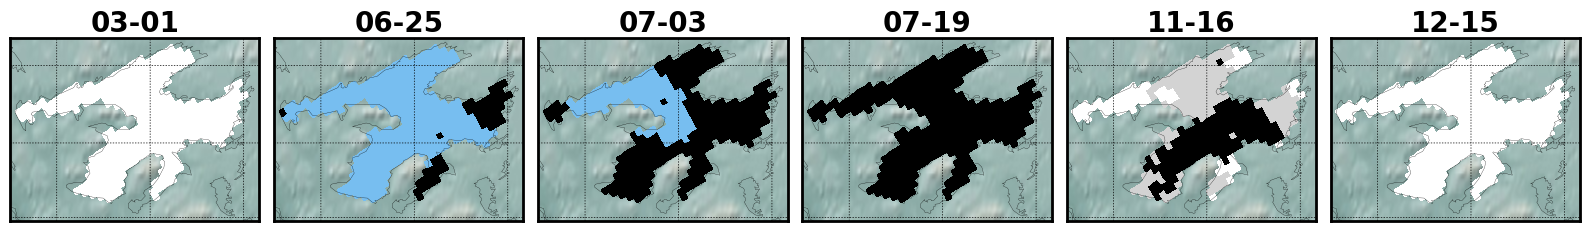

In [8]:
"""
ice_phenology_plot
=====================
SMAP Lake Ice Phenology Visualization — Great Bear Lake (2018)

Maps the ice phenology state of each SMAP pixel for a given day-of-year (DOY)
by comparing the DOY against the four detected breakpoints per pixel:

Ice State Classification (by DOY relative to breakpoints):
    DOY < BP0            → 1 = Winter ice (frozen, pre-melt)
    BP0 <= DOY < BP1     → 2 = Melting
    BP1 <= DOY < BP2     → 3 = Open water
    BP2 <= DOY < BP3     → 4 = Freezing
    DOY >= BP3           → 5 = Frozen (post freeze-up)

Color Map:
    State 1 (winter ice)  → white
    State 2 (melting)     → #77BEF0  (light blue)
    State 3 (open water)  → black
    State 4 (freezing)    → lightgray
    State 5 (frozen)      → white
"""

# ---------------------------------------------------------------------------
# Colormap Configuration
# ---------------------------------------------------------------------------

# One color per ice state (indices 1–5), plus a background color at index 0.
# The BoundaryNorm maps continuous values to discrete color bins:
#   [0.5–1.5) → white      (state 1: winter ice)
#   [1.5–2.5) → #77BEF0   (state 2: melting)
#   [2.5–3.5) → black      (state 3: open water)
#   [3.5–4.5) → lightgray  (state 4: freezing)
#   [4.5–5.5) → white      (state 5: frozen post freeze-up)
#   [5.5–10)  → #91C8E4   (background / non-lake pixels)
COLORMAP_COLORS = ['white', '#77BEF0', 'black', 'lightgray', 'white', '#91C8E4']
COLORMAP_BOUNDS = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 10]

cmap = ListedColormap(COLORMAP_COLORS)
norm = BoundaryNorm(COLORMAP_BOUNDS, cmap.N)

# Font size used for graticule labels
LABEL_FONTSIZE = 6


# ---------------------------------------------------------------------------
# SMAP Ice State Mapping and Plotting
# ---------------------------------------------------------------------------

def plot_smap(current_doy, date_data, ax,
              llcrnrlat=64.7, urcrnrlat=67.1,
              llcrnrlon=-125.3, urcrnrlon=-117.3):
    """
    Plot the SMAP-derived ice phenology state for a given day-of-year (DOY).

    For each SMAP pixel in the 2000×2000 grid, the pixel's detected breakpoints
    are compared against `current_doy` to assign one of five ice states.

    Parameters
    ----------
    current_doy : int
        Day-of-year to visualize (1–366).
    date_data : list of list
        2000×2000 grid where each cell is either:
            - A list of four breakpoints [BP0, BP1, BP2, BP3] (DOY integers), or
            - A non-list value (NaN) for non-lake pixels.
    ax : matplotlib.axes.Axes
        Axes object on which to draw the map.
    llcrnrlat : float, optional
        Lower-left corner latitude of the map extent (default: 64.7).
    urcrnrlat : float, optional
        Upper-right corner latitude of the map extent (default: 67.1).
    llcrnrlon : float, optional
        Lower-left corner longitude of the map extent (default: -125.3).
    urcrnrlon : float, optional
        Upper-right corner longitude of the map extent (default: -117.3).

    Returns
    -------
    None
        Draws directly onto `ax`.
    """
    # --- Classify each pixel into an ice state ---
    temp = np.zeros((2000, 2000))

    for i in range(2000):
        for j in range(2000):
            if isinstance(date_data[i][j], list):
                bps = date_data[i][j]
                if len(bps) != 4:
                    temp[i, j] = np.nan
                    continue
                bp0, bp1, bp2, bp3 = bps

                if current_doy < bp0:
                    temp[i, j] = 1   # Winter ice (pre-melt)
                elif current_doy < bp1:
                    temp[i, j] = 2   # Melting phase
                elif current_doy < bp2:
                    temp[i, j] = 3   # Open water
                elif current_doy < bp3:
                    temp[i, j] = 4   # Freezing phase
                else:
                    temp[i, j] = 5   # Frozen (post freeze-up)
            else:
                # Non-lake pixel — assign NaN (rendered as background color)
                temp[i, j] = np.nan

    # Anchor all five state values into the top-left corner so pcolormesh
    # registers all colors in the colormap (these pixels are outside the
    # plotted geographic extent and are not visible on the final map).
    for state in range(5):
        temp[0, state] = state

    # --- Build Mercator basemap ---
    m = Basemap(
        projection='merc',
        llcrnrlat=llcrnrlat, urcrnrlat=urcrnrlat,
        llcrnrlon=llcrnrlon, urcrnrlon=urcrnrlon,
        resolution='i',
        ax=ax
    )

    m.drawcoastlines(linewidth=0.2)
    m.drawcountries(linewidth=0.2)

    # Draw graticule lines (parallels and meridians) without tick labels
    parallels = np.arange(llcrnrlat + 0.05, urcrnrlat, 1)
    meridians = np.arange(llcrnrlon + 1.5,  urcrnrlon, 3)

    m.drawparallels(parallels, labels=[0, 0, 0, 0],
                    fontsize=LABEL_FONTSIZE, linewidth=0.5, dashes=[2, 2])
    m.drawmeridians(meridians, labels=[0, 0, 0, 0],
                    fontsize=LABEL_FONTSIZE, linewidth=0.5, dashes=[2, 2])

    # Add shaded relief as a base layer for geographic context
    m.shadedrelief()

    # Project SMAP grid coordinates to map coordinates and overlay ice states
    x, y = m(polar_lon.T, polar_lat.T)
    m.pcolormesh(x, y, temp, cmap=cmap, norm=norm, shading='auto')

    # Thicken the map border for visual clarity
    for spine in ax.spines.values():
        spine.set_linewidth(2)
        spine.set_edgecolor('black')

def doy_to_mmdd(doy, year=2018):
    """
    Convert a day-of-year (DOY) to a 'MM-DD' string.

    Parameters
    ----------
    doy  : int  Day of year (1–366).
    year : int  Year, used to handle leap years correctly (default: 2018).

    Returns
    -------
    str  Date string in 'MM-DD' format, e.g. 174 -> '06-23'.
    """
    date = datetime.datetime(year, 1, 1) + datetime.timedelta(days=doy - 1)
    return date.strftime('%m-%d')

# ---------------------------------------------------------------------------
# Multi-Panel Plot: Selected DOYs for Great Bear Lake (2018)
# ---------------------------------------------------------------------------
plot_doys = [60, 176, 184, 200, 320, 349]

fig, axes = plt.subplots(1, len(plot_doys), figsize=(16, 6))

for i, doy in enumerate(plot_doys):
    plot_smap(doy, data, axes[i])
    axes[i].set_title(f'{doy_to_mmdd(doy)}', fontsize=20, pad=3, fontweight = 'bold')

plt.tight_layout()
plt.show()

## 3.2. Calibration of Tikhonov regularization parameters

In [78]:
"""
inverse_wetness_estimation
==========================
Retrieval of Snow and Ice Liquid Water Content via Constrained Optimization

Inverts dual-polarization brightness temperatures (Tbh, Tbv) to simultaneously
retrieve snow wetness (ws) and ice wetness (wi) using the trust-region
constrained minimization method.

Physical constraint:
    ws >= wi  —  snow begins melting before ice, so snow liquid water content
                 is always greater than or equal to that of ice.

Objective:
    Minimizes the sum of squared Tb residuals with Tikhonov-style regularization
    terms that penalize non-zero wetness, weighted asymmetrically to reflect that
    ice wetness (wi) is physically harder to achieve than snow wetness (ws):

        J(ws, wi) = ||Tb_sim - Tb_obs||² + λ_s·ws² + λ_i·wi²

    λ_s and λ_i are calibrated externally and passed as function arguments.
"""



# ---------------------------------------------------------------------------
# Parameter bounds (shared across safety clip, solver bounds, and output clip)
# ---------------------------------------------------------------------------
_WS_MIN, _WS_MAX = 0.0, 0.10   # Snow wetness bounds (fraction)
_WI_MIN, _WI_MAX = 0.0, 0.06   # Ice wetness bounds  (fraction)

# Default initial guess for [ws, wi]
_DEFAULT_INITIAL_GUESS = [0.02, 0.01]


def inverse_wetness_estimation(WaterParams, IceParams, SnowParams, RoughnessParams,
                                TBs, forward_function,
                                lam_snow=0.1, lam_ice=81.6,
                                full_answer=False, initial_guess=None):
    """
    Retrieve snow wetness (ws) and ice wetness (wi) by inverting observed
    brightness temperatures via constrained nonlinear optimization.

    Parameters
    ----------
    WaterParams      : dict        Water layer parameters for the forward model.
    IceParams        : dict        Ice layer parameters (ws and wi will be injected).
    SnowParams       : dict        Snow layer parameters (ws and wi will be injected).
    RoughnessParams  : dict        Surface roughness parameters.
    TBs              : array-like  Observed [Tbh, Tbv] in Kelvin.
    forward_function : callable    Forward emission model with signature:
                                   f(WaterParams, IceParams, SnowParams, RoughnessParams)
                                   -> (Tbh, Tbv)
    lam_snow         : float       Regularization weight for snow wetness (λ_s).
                                   Default: 0.1.
    lam_ice          : float       Regularization weight for ice wetness (λ_i).
                                   Default: 82.0.
    full_answer      : bool        If True, return the full scipy OptimizeResult.
                                   If False (default), return clipped [ws, wi] array.
    initial_guess    : list, optional
                                   Starting point [ws0, wi0] for the optimizer.
                                   Defaults to [0.02, 0.01].

    Returns
    -------
    np.ndarray or OptimizeResult
        Optimized [ws, wi] clipped to valid bounds (full_answer=False), or the
        full scipy OptimizeResult object (full_answer=True).
    """
    if initial_guess is None:
        initial_guess = _DEFAULT_INITIAL_GUESS

    # Convert observations once — the objective is called hundreds of times
    TBs_array = np.asarray(TBs, dtype=np.float64)

    def objective_function(wetness_params):
        # Safety clip: prevents the forward model from receiving out-of-bound
        # values during the solver's internal finite-difference gradient probes
        ws = np.clip(wetness_params[0], _WS_MIN, _WS_MAX)
        wi = np.clip(wetness_params[1], _WI_MIN, _WI_MAX)

        SnowP = {**SnowParams, 'WSnow': ws}
        IceP  = {**IceParams,  'WIce':  wi}

        try:
            tbh_t, tbv_t = forward_function(
                WaterParams, IceP, SnowP, RoughnessParams
            )
            residuals = np.array([tbh_t, tbv_t], dtype=np.float64) - TBs_array
            penalty   = np.array([lam_snow * ws**2, lam_ice * wi**2])
            return np.sum(residuals**2) + np.sum(penalty)

        except (ValueError, ZeroDivisionError):
            # Return a large penalty if the forward model hits a numerical error
            return 1e12

    # Linear constraint: ws - wi >= 0  (snow wetness >= ice wetness)
    ws_ge_wi = LinearConstraint([[1, -1]], lb=0.0, ub=np.inf)

    # Box bounds: ws in [0, 0.1], wi in [0, 0.06]
    bounds = [(_WS_MIN, _WS_MAX), (_WI_MIN, _WI_MAX)]

    result = minimize(
        objective_function,
        initial_guess,
        method='trust-constr',
        bounds=bounds,
        constraints=[ws_ge_wi],
        options={
            'xtol': 1e-10,
            'gtol': 1e-10,
            'barrier_tol': 1e-10,
            # Reduced relative step size for finite-difference gradient estimation;
            # necessary because ws and wi are small (~1e-2) and the default step
            # would overshoot the meaningful range of the Tb curves
            'finite_diff_rel_step': 1e-4,
        }
    )

    if full_answer:
        return result

    return np.clip(result.x, [_WS_MIN, _WI_MIN], [_WS_MAX, _WI_MAX])

In [10]:
def generate_constrained_samples(n_target, seed=None):
    """
    Generate random (wi, ws) pairs uniformly sampled from the feasible region
    defined by the box bounds and the physical constraint wi <= ws.

    Sampling is done in batches and filtered until `n_target` valid pairs are
    collected. Each batch draws `n_target` candidates, so convergence is fast
    (the constraint wi <= ws retains ~50% of uniform samples on average).

    Parameters
    ----------
    n_target : int            Number of valid (wi, ws) pairs to return.
    seed     : int, optional  Random seed for reproducibility.

    Returns
    -------
    wi : np.ndarray  Ice wetness samples of shape (n_target,), in [0, 0.06].
    ws : np.ndarray  Snow wetness samples of shape (n_target,), in [0, 0.10],
                     with ws >= wi enforced for every pair.
    """
    rng = np.random.default_rng(seed)
    wi_all, ws_all = [], []

    while len(wi_all) < n_target:
        wi_batch = rng.uniform(0, 0.06, n_target)
        ws_batch = rng.uniform(0, 0.10, n_target)

        # Retain only pairs satisfying the physical constraint wi <= ws
        mask = wi_batch <= ws_batch
        wi_all.extend(wi_batch[mask])
        ws_all.extend(ws_batch[mask])

    return np.array(wi_all[:n_target]), np.array(ws_all[:n_target])


wi_random, ws_random = generate_constrained_samples(100, seed=42)

In [11]:
rng = np.random.default_rng(0)
noise = rng.normal(0, 1, size = len(ws_random)).astype(np.float64)

len(noise), len(ws_random), len(wi_random)

(100, 100, 100)

In [12]:
WaterParams = {'TWater': 0.01}
IceParams = {'TIce': -0.01, 'dIce': 1.3, 'WIce': 0}
SnowParams = {'TSnow': -0.01, 'WSnow': 0, 'dSnow': 0.25}
RoughnessParams = {'rough_wi': np.array([0, 0, 2.0, 2.0])}

In [48]:
# Fixed seed for reproducibility — must match the seed used in calibration_setup.py
rng_thickness = np.random.default_rng(42)
 
hs = rng_thickness.uniform(0.05, 0.40, len(ws_random))   # Snow depth (m)
hi = rng_thickness.uniform(1.00, 1.30, len(ws_random))   # Ice thickness (m)
 
# λ_s is held fixed; only λ_i is searched over the calibration grid
lam_s_grid = [0.1, 10, 100, 500]
lam_i_grid = [0.1, 10, 100, 250, 500, 750, 1000, 2500, 5000, 7500, 10000]

In [49]:
TBh_obs = np.empty(len(wi_random), dtype=np.float64)
TBv_obs = np.empty(len(wi_random), dtype=np.float64)

for i in range(len(wi_random)):
    IceP  = {**IceParams,  'dIce': hi[i], 'WIce': wi_random[i]}
    SnowP = {**SnowParams, 'dSnow': hs[i], 'WSnow': ws_random[i]}

    tbh, tbv = LakeIceEmit(WaterParams, IceP, SnowP, RoughnessParams)

    # Add identical noise to both polarizations
    TBh_obs[i] = tbh + noise[i]
    TBv_obs[i] = tbv + noise[i]

In [50]:
ws0_vals = np.linspace(0.0, 0.1 , 11, dtype = np.float64)
wi0_vals = np.linspace(0.0, 0.06, 7, dtype = np.float64)

initial_guesses2 = []

for ws in ws0_vals:
    for wi in wi0_vals:
        if wi<=ws:
            initial_guesses2.append([ws, wi])
initial_guesses2 = np.array(initial_guesses2, dtype = np.float64)

In [51]:
# Threshold below which best_result.fun is considered a valid inversion
# (values near 1e12 indicate the forward model failed on every starting point)
_PENALTY_SENTINEL = 1e6
 
 
def compute_l_surface(lam_s_grid, lam_i_grid,
                      TBh_obs, TBv_obs,
                      hi, hs,
                      WaterParams, IceParams, SnowParams, RoughnessParams,
                      forward_function, initial_guesses):
    """
    Evaluate residual norm and solution norm over a (lam_s, lam_i) grid.
 
    For each lambda pair, runs multi-start inversion on every observation
    sample and records the mean data misfit and mean solution norm. Results
    are stored as 2D surfaces indexed by [i_lam_s, i_lam_i].
 
    Parameters
    ----------
    lam_s_grid       : list of float   Candidate λ_s values (snow wetness penalty).
    lam_i_grid       : list of float   Candidate λ_i values (ice wetness penalty).
    TBh_obs          : np.ndarray      Observed H-pol Tb (K), shape (N,).
    TBv_obs          : np.ndarray      Observed V-pol Tb (K), shape (N,).
    hi               : np.ndarray      Per-sample ice thickness (m), shape (N,).
    hs               : np.ndarray      Per-sample snow depth (m), shape (N,).
    WaterParams      : dict            Water layer parameters (shared across samples).
    IceParams        : dict            Ice layer base parameters; dIce and WIce
                                       are injected per sample during inversion.
    SnowParams       : dict            Snow layer base parameters; dSnow and WSnow
                                       are injected per sample during inversion.
    RoughnessParams  : dict            Roughness parameters.
    forward_function : callable        Forward emission model (e.g. LakeIceEmit).
    initial_guesses  : list of list    Multi-start initial guesses [[ws0, wi0], ...].
 
    Returns
    -------
    residual_surface      : np.ndarray  Mean residual norm,  shape (ns, ni).
    solution_norm_surface : np.ndarray  Mean solution norm,  shape (ns, ni).
    ws_hat_surface        : np.ndarray  Mean retrieved ws,   shape (ns, ni).
    wi_hat_surface        : np.ndarray  Mean retrieved wi,   shape (ns, ni).
    """
    N  = len(TBh_obs)
    ns = len(lam_s_grid)
    ni = len(lam_i_grid)
 
    residual_surface      = np.full((ns, ni), np.nan)
    solution_norm_surface = np.full((ns, ni), np.nan)
    ws_hat_surface        = np.full((ns, ni), np.nan)
    wi_hat_surface        = np.full((ns, ni), np.nan)
 
    with tqdm(total=ns * ni, desc="L-surface grid search") as pbar:
        for a, lam_s in enumerate(lam_s_grid):
            for b, lam_i in enumerate(lam_i_grid):
 
                residuals      = np.full(N, np.nan)
                solution_norms = np.full(N, np.nan)
                ws_hats        = np.full(N, np.nan)
                wi_hats        = np.full(N, np.nan)
 
                for k in range(N):
                    TBs = np.array([TBh_obs[k], TBv_obs[k]], dtype=np.float64)
 
                    # Inject per-sample geometry — this is the critical step that
                    # was missing: without dIce and dSnow, LakeIceEmit raises
                    # ValueError and the objective returns the 1e12 sentinel
                    IceP  = {**IceParams,  'dIce':  hi[k]}
                    SnowP = {**SnowParams, 'dSnow': hs[k]}
 
                    best_cost   = np.inf
                    best_result = None
 
                    for ig in initial_guesses:
                        try:
                            result = inverse_wetness_estimation(
                                WaterParams, IceP, SnowP, RoughnessParams,
                                TBs, forward_function,
                                lam_snow=lam_s, lam_ice=lam_i,
                                full_answer=True, initial_guess=ig
                            )
                        except Exception:
                            continue
 
                        if result.fun < best_cost:
                            best_cost   = result.fun
                            best_result = result
 
                    # Skip sample if all starting points failed, or if the
                    # objective hit the 1e12 penalty on every evaluation
                    if best_result is None or best_result.fun > _PENALTY_SENTINEL:
                        continue
 
                    # Clip to valid bounds — solver can marginally exceed them
                    ws_hat = np.clip(best_result.x[0], _WS_MIN, _WS_MAX)
                    wi_hat = np.clip(best_result.x[1], _WI_MIN, _WI_MAX)
 
                    # Extract data misfit by subtracting the regularization penalty
                    # from the total objective value (recomputed from clipped values)
                    penalty           = lam_s * ws_hat**2 + lam_i * wi_hat**2
                    residuals[k]      = best_result.fun - penalty
                    solution_norms[k] = ws_hat**2 + wi_hat**2
                    ws_hats[k]        = ws_hat
                    wi_hats[k]        = wi_hat
 
                residual_surface[a, b]      = np.nanmean(residuals)
                solution_norm_surface[a, b] = np.nanmean(solution_norms)
                ws_hat_surface[a, b]        = np.nanmean(ws_hats)
                wi_hat_surface[a, b]        = np.nanmean(wi_hats)
 
                pbar.set_postfix({
                    'lam_s':    f'{lam_s:.1e}',
                    'lam_i':    f'{lam_i:.1e}',
                    'resid':    f'{residual_surface[a, b]:.4f}',
                    'sol_norm': f'{solution_norm_surface[a, b]:.6f}'
                })
                pbar.update(1)
 
    return residual_surface, solution_norm_surface, ws_hat_surface, wi_hat_surface

In [52]:
# # ---------------------------------------------------------------------------
# # Run calibration
# # ---------------------------------------------------------------------------
 
# residual_surface, solution_norm_surface, ws_hat_surface, wi_hat_surface = compute_l_surface(
#     lam_s_grid       = lam_s_grid,
#     lam_i_grid       = lam_i_grid,
#     TBh_obs          = TBh_obs,
#     TBv_obs          = TBv_obs,
#     hi               = hi,
#     hs               = hs,
#     WaterParams      = WaterParams,
#     IceParams        = IceParams,
#     SnowParams       = SnowParams,
#     RoughnessParams  = RoughnessParams,
#     forward_function = LakeIceEmit,
#     initial_guesses  = initial_guesses2
# )

# np.savez(
#     "Demo data/lambda_surface_with_constraints.npz",
#     lam_s_grid=lam_s_grid,
#     lam_i_grid=lam_i_grid,
#     ws_hat_surface = ws_hat_surface,
#     wi_hat_surface = wi_hat_surface,
#     misfit_surface=misfit_surface,
#     solution_norm_surface=solution_norm_surface,
#     total_surface=total_surface
# )

**The codes for running calibration are commented out as it takes considerable amount of time (several hours to days) to run. However, the codes are provided.**

In [53]:
def find_curvature():
    """
    Find the optimal Tikhonov regularization parameter λ_i using the
    L-curve criterion. The corner of the L-curve — where the curvature
    is maximum — identifies the optimal trade-off between data misfit
    and solution norm.

    The smoothing factor for the spline fit is selected automatically
    via leave-one-out cross-validation over a log-spaced candidate grid,
    avoiding any manual tuning.

    Returns
    -------
    opt_lam    : float       Optimal λ_i in linear scale.
    curvature  : np.ndarray  Curvature of the L-curve on the fine grid
                             (negative values clipped to zero).
    log_lam_fine : np.ndarray  Fine λ_i grid in log10 scale.
    """
    with np.load('Demo data/lambda_surface_with_constraints.npz') as data:
        lam_i    = data['lam_i_grid']
        misfit   = data['misfit_surface'][0]        # λ_s = 0.1 fixed
        sol_norm = data['solution_norm_surface'][0]

    # Transform to log-log space — standard for L-curve analysis
    log_lam  = np.log10(lam_i)
    log_rho  = np.log10(misfit)
    log_xi   = np.log10(sol_norm)

    # Select smoothing factor via leave-one-out cross-validation
    s_candidates = np.logspace(-4, 0, 50)

    def _loo_error(log_x, log_y, s):
        """Leave-one-out cross-validation error for a given s."""
        err = 0.0
        for j in range(len(log_x)):
            mask = np.ones(len(log_x), dtype=bool)
            mask[j] = False
            spl = UnivariateSpline(log_x[mask], log_y[mask], k=3, s=s)
            err += (spl(log_x[j]) - log_y[j]) ** 2
        return err

    # Choose s that minimises LOO error for both curves jointly
    loo_errors = np.array([
        _loo_error(log_lam, log_rho, s) + _loo_error(log_lam, log_xi, s)
        for s in s_candidates
    ])
    best_s = s_candidates[np.argmin(loo_errors)]

    # Fit smoothing splines with the selected s
    spl_rho = UnivariateSpline(log_lam, log_rho, k=3, s=best_s)
    spl_xi  = UnivariateSpline(log_lam, log_xi,  k=3, s=best_s)

    # Evaluate on a fine grid (2000 points) for smooth curvature estimation
    log_lam_fine = np.linspace(log_lam.min(), log_lam.max(), 2000)
    lam_fine     = 10 ** log_lam_fine

    x = spl_rho(log_lam_fine)   # log residual norm
    y = spl_xi(log_lam_fine)    # log solution norm

    # Geometric curvature of the parametric L-curve in log-log space:
    #   κ = (x'y'' - y'x'') / (x'^2 + y'^2)^(3/2)
    dx  = np.gradient(x, log_lam_fine)
    dy  = np.gradient(y, log_lam_fine)
    ddx = np.gradient(dx, log_lam_fine)
    ddy = np.gradient(dy, log_lam_fine)

    curvature = (dx * ddy - dy * ddx) / (dx ** 2 + dy ** 2) ** 1.5
    curvature  = np.maximum(curvature, 0)   # discard concave regions

    if np.all(curvature == 0):
        raise ValueError(
            "No positive curvature found — the L-curve has no elbow "
            "in this λ_i range. Consider extending lam_i_grid."
        )

    opt_lam = lam_fine[np.argmax(curvature)]
    return opt_lam, curvature, log_lam_fine

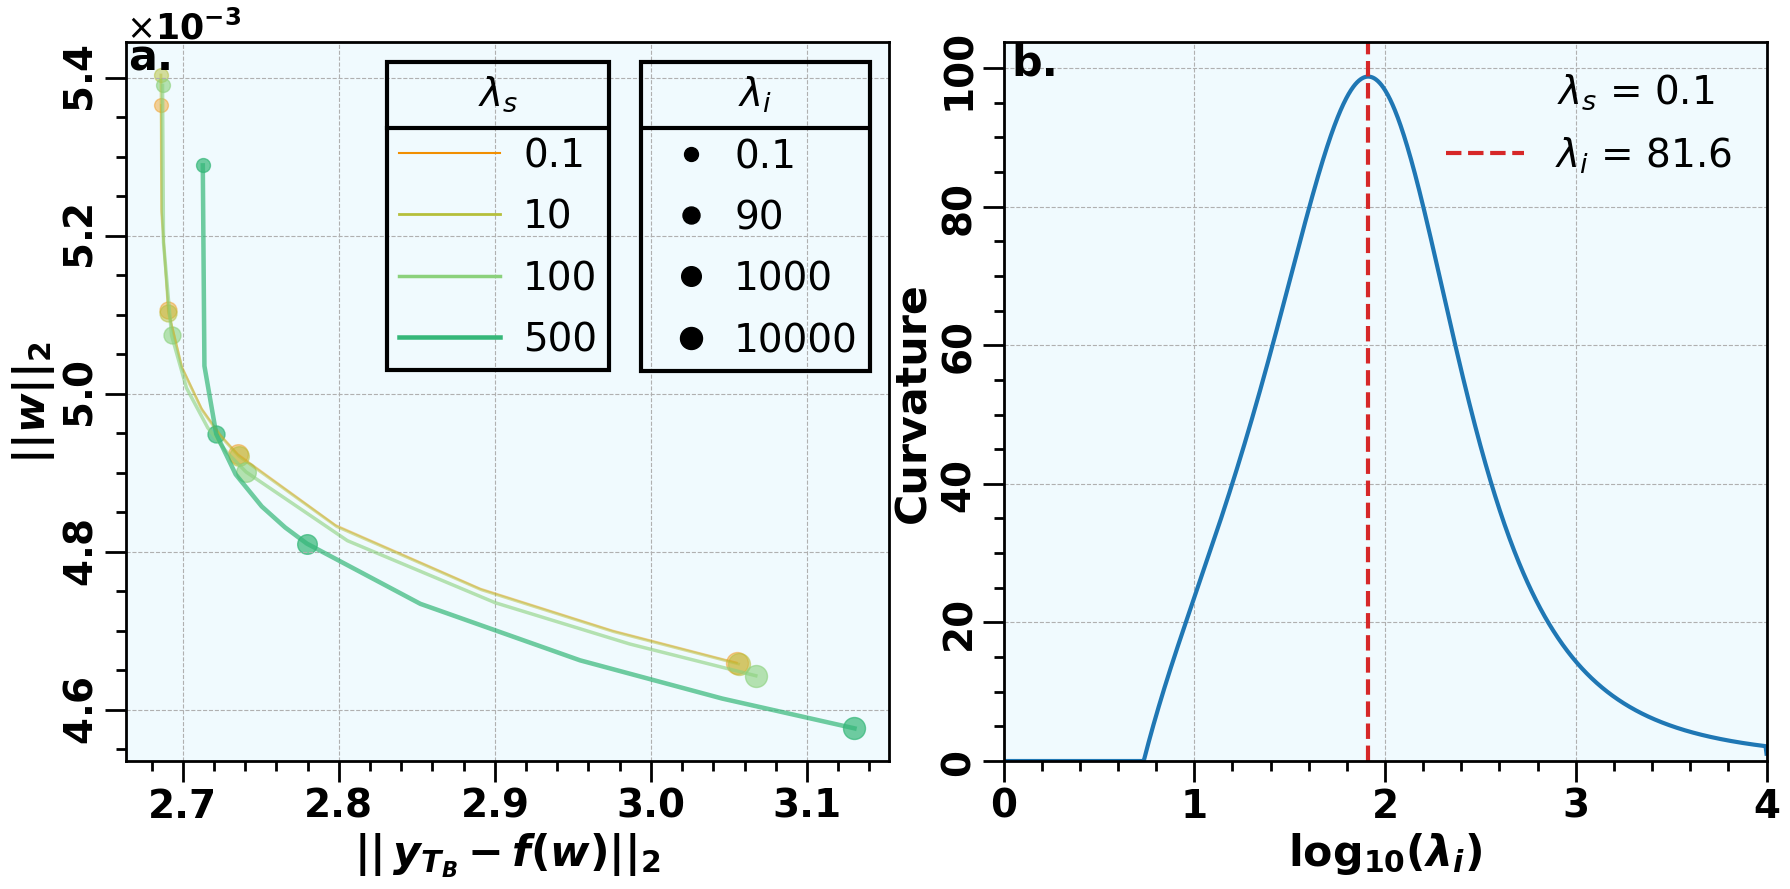

In [77]:
"""
L-curve and Curvature Plots for Tikhonov Regularization Parameter Selection

Two-panel figure:
    Left  (a) : L-curve — residual norm vs. solution norm for all (λ_s, λ_i) pairs.
    Right (b) : Curvature of the L-curve as a function of log10(λ_i), with the
                optimal λ_i identified at the maximum curvature (corner of the L).
"""

# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
COLORS     = ["#F18F01", "#B5BF3B", "#8BD17C", "#35B779"]
LWS        = [1.5, 2, 2.5, 3.25]
MSS        = [100, 150, 200, 250]
ALPHAS     = [0.3, 0.4, 0.5, 0.6]
L_S        = list(range(4))
L_I        = [0, 2, 6, 10]
fz         = 28
spwid      = 2
ticklength = 15

# ---------------------------------------------------------------------------
# Load data
# ---------------------------------------------------------------------------
with np.load('Demo data/lambda_surface_with_constraints.npz') as data:
    lam_i    = data['lam_i_grid']
    lam_s    = data['lam_s_grid']
    residual = np.square(data['misfit_surface'])
    solnorm  = np.square(data['solution_norm_surface'])

opt_lam_i, curvature, log_lam = find_curvature()

# ---------------------------------------------------------------------------
# Figure and axes
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(18, 9))

for a in ax:
    a.set_facecolor("#f0fafe")
    a.grid(True, axis='both', linestyle='--', alpha=1)
    for spine in a.spines.values():
        spine.set_linewidth(spwid)
        spine.set_edgecolor('black')
    a.tick_params(axis='both', which='major',
                  length=ticklength, width=spwid, labelsize=fz, color='black')
    a.tick_params(axis='both', which='minor',
                  length=ticklength / 2, width=spwid,
                  labelbottom=False, labelleft=False)
    a.minorticks_on()
    for label in a.get_xticklabels() + a.get_yticklabels():
        label.set_fontweight('bold')
    for label in a.get_yticklabels():
        label.set_rotation(90)
        label.set_verticalalignment('center')
        label.set_horizontalalignment('right')

# ---------------------------------------------------------------------------
# Left panel (a): L-curve
# ---------------------------------------------------------------------------
for ind, i in enumerate(L_S):
    ax[0].plot(
        np.sqrt(residual[i, :]), np.sqrt(solnorm[i, :]),
        color=COLORS[ind], lw=LWS[ind], alpha=ALPHAS[ind] + 0.1
    )

for indi, i in enumerate(L_S):
    for ind, j in enumerate(L_I):
        ax[0].scatter(
            np.sqrt([residual[i, j]]), np.sqrt([solnorm[i, j]]),
            marker='o', s=MSS[ind],
            alpha=ALPHAS[indi] + 0.1, color=COLORS[indi]
        )

formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-3, -4))
ax[0].yaxis.set_major_formatter(formatter)
ax[0].yaxis.get_offset_text().set_fontsize(25)
ax[0].yaxis.get_offset_text().set_fontweight('bold')

ax[0].set_xlabel(
    r"$\mathbfit{||\,y_{T_B} - f\mathbf{(}\boldsymbol{w}\mathbf{)}||_\mathbf{2}}$",
    fontsize=fz * 1.1, fontweight='bold'
)
ax[0].set_ylabel(
    r"$\mathbfit{||w||_\mathbf{2}}$",
    fontsize=fz * 1.1, fontweight='bold'
)
ax[0].text(2.665, 5.41e-3, "a.", fontsize=fz * 1.1, fontweight='bold')

# ---------------------------------------------------------------------------
# Right panel (b): Curvature
# ---------------------------------------------------------------------------
ax[1].plot(log_lam, curvature, color='tab:blue', lw=3)
ax[1].axvline(np.log10(opt_lam_i), color='tab:red', linestyle='dashed', lw=3,
              label=r"$\lambda_i$ = "+f"{round(opt_lam_i,1)}")
ax[1].set_xlabel(r"$\mathbf{log_{10}(\mathbfit{\lambda_i})}$", fontsize=fz * 1.1)
ax[1].set_ylabel("Curvature", fontsize=fz * 1.1, fontweight = 'bold')
ax[1].set_xlim(xmin=0, xmax=4)
ax[1].set_ylim(ymin=0)
ax[1].text(0.04, 99,  "b.",             fontsize=fz * 1.1, fontweight='bold')
ax[1].text(2.9, 95,  r"$\lambda_s$ = 0.1", fontsize=fz)
ax[1].legend(prop={'size': fz}, frameon=False,
             loc='upper right', bbox_to_anchor=(1, 0.92))

# ---------------------------------------------------------------------------
# Legends for left panel
# ---------------------------------------------------------------------------
lambda_i_handles = [
    mlines.Line2D(
        [], [], marker='o', color='black', linestyle='None',
        markersize=np.sqrt(MSS[ind]),
        label=f"{round(lam_i[j], 3)}" if lam_i[j] < 1 else f"{int(lam_i[j])}"
    )
    for ind, j in enumerate(L_I)
]
leg_i = ax[0].legend(
    handles=lambda_i_handles,
    title=r"$\lambda_i$", title_fontsize=fz, fontsize=fz,
    loc='upper right', frameon=True, fancybox=False,
    framealpha=1.0, borderpad=0.3, labelspacing=0.6,
    handlelength=2, handletextpad=0.1,
)
leg_i.get_frame().set_facecolor('none')
leg_i.get_frame().set_edgecolor('black')
leg_i.get_frame().set_linewidth(3)

fig.canvas.draw()
bbox     = leg_i.get_window_extent()
bbox_fig = bbox.transformed(fig.transFigure.inverted())
x0 = bbox_fig.x0 + 0.17 * bbox_fig.width
x1 = bbox_fig.x1 + 0.15 * bbox_fig.width
y  = bbox_fig.y1 - 0.02 * bbox_fig.height
fig.lines.append(plt.Line2D([x0, x1], [y, y],
                             transform=fig.transFigure, color='black', linewidth=3))
ax[0].add_artist(leg_i)

lambda_s_handles = [
    mlines.Line2D([], [], color=COLORS[k], lw=LWS[k], label=f"{lam_s[k]:g}")
    for k in range(4)
]
bbox_i_ax = leg_i.get_window_extent(
    fig.canvas.get_renderer()
).transformed(ax[0].transAxes.inverted())

leg_s = ax[0].legend(
    handles=lambda_s_handles,
    title=r"$\lambda_s$", title_fontsize=fz, fontsize=fz,
    loc='upper right',
    bbox_to_anchor=(bbox_i_ax.x0 + 0.05, bbox_i_ax.y1 + 0.028),
    frameon=True, fancybox=False, framealpha=1.0,
    borderpad=0.3, labelspacing=0.6,
    handlelength=2.6, handletextpad=0.6,
)
leg_s.get_frame().set_facecolor('none')
leg_s.get_frame().set_edgecolor('black')
leg_s.get_frame().set_linewidth(3)

fig.canvas.draw()
bbox     = leg_s.get_window_extent()
bbox_fig = bbox.transformed(fig.transFigure.inverted())
x0 = bbox_fig.x0 - 0.04 * bbox_fig.width
x1 = bbox_fig.x1 - 0.05 * bbox_fig.width
y  = bbox_fig.y1 - 0.02  * bbox_fig.height
fig.lines.append(plt.Line2D([x0, x1], [y, y],
                             transform=fig.transFigure, color='black', linewidth=3))

# ---------------------------------------------------------------------------
# Layout and save
# ---------------------------------------------------------------------------
plt.tight_layout()
plt.subplots_adjust(wspace=0.15)
plt.show()

## 3.3. XGBoost based detection-estimation framework

In [17]:
def split_by_year(data, start_date="2015-03-31"):
    """
    Splits a daily time-series array into yearly arrays.
    
    Parameters
    ----------
    data : numpy array
        Daily data in chronological order.
    start_date : str
        Starting date of the data in YYYY-MM-DD format.

    Returns
    -------
    list_of_arrays : list
        A list where each element is a numpy array containing
        the data for one calendar year.
    """
    start = datetime.datetime.strptime(start_date, "%Y-%m-%d")

    year_arrays = []
    idx = 0
    
    current = start
    
    while idx < len(data):
        # Start and end of the current year
        year_start = datetime.datetime(current.year, 1, 1)
        
        # If starting mid-year (e.g., 2015)
        if current.year == start.year:
            year_start = start
        
        # Last day of the current year
        year_end = datetime.datetime(current.year, 12, 31)
        
        # Number of days in this partial/full year segment
        days = (year_end - current).days + 1
        
        # Extract that segment
        segment = data[idx : idx + days]
        
        year_arrays.append(segment)
        
        # Advance
        idx += days
        current = year_end + datetime.timedelta(days=1)
        
        if idx >= len(data):
            break

    return year_arrays

In [18]:
all_lakes = []
lakes_name = ['Great Bear']
for i in polar_lake_data:
    if i['Name'] in lakes_name and i['Water fraction'] == 1.0:
        all_lakes.append(i)
len(all_lakes)

55

In [19]:
dictionary = {i:0 for i in lakes_name}
for i in all_lakes:
    if i['Water fraction'] == 1.0 and i['Name'] in lakes_name:
        dictionary[i['Name']] += 1
dictionary

{'Great Bear': 55}

### 3.3.1. Detection

In [20]:
"""
xgboost_data_prep
====================
Train/Test Split Preparation for Lake Ice Phenology XGBoost Model

Splits multi-year SMAP Tb (H and V polarization) time series across all lakes
into training and test sets. The year index mapping after stripping 2015 is:

    Index : Year : Split
    ------+------+----------------------------
      0   : 2016 : Test  (held out)
      1   : 2017 : Train
      2   : 2018 : Train
      3   : 2019 : Excluded (>2 months missing)
      4   : 2020 : Train
      5   : 2021 : Train
      6   : 2022 : Train
      7   : 2023 : Train
      8   : 2024 : Train

Notes:
    - 2015 is dropped entirely (incomplete year).
    - 2016 is reserved as the held-out test year for all lakes.
    - 2019 is excluded from training due to extended data gaps (>2 months).
"""

# Year indices (post-2015) used for training; index 3 (2019) intentionally skipped
TRAIN_INDICES = [1, 2, 4, 5, 6, 7, 8]   # 2017, 2018, 2020–2024
TEST_INDEX    = 0                          # 2016

# Accumulators for Tb time series and lake identity labels
Tbh_train, Tbv_train = [], []
Tbh_test,  Tbv_test  = [], []

for lake in all_lakes:
    # Split the full Tb record into per-year segments; drop index 0 (2015)
    tbh_by_year = split_by_year(lake['tbh uncorrected'])[1:]
    tbv_by_year = split_by_year(lake['tbv uncorrected'])[1:]

    # Training years
    for i in TRAIN_INDICES:
        Tbh_train.append(tbh_by_year[i])
        Tbv_train.append(tbv_by_year[i])

    # Test year (2016)
    Tbh_test.append(tbh_by_year[TEST_INDEX])
    Tbv_test.append(tbv_by_year[TEST_INDEX])

# Sanity check: confirm expected list lengths
print(f"Train samples : {len(Tbh_train)} Tbh, {len(Tbv_train)} Tbv")
print(f"Test  samples : {len(Tbh_test)}  Tbh, {len(Tbv_test)}  Tbv")

Train samples : 385 Tbh, 385 Tbv
Test  samples : 55  Tbh, 55  Tbv


In [21]:
"""
melt_phase_detection
=======================
Sub-period Detection within the Lake Ice Melt Season

During spring melt, L-band brightness temperatures (Tb) exhibit a characteristic
three-stage pattern:

    M1 — Initial hump: Tb rises as snow/ice starts melting (wet snow emission).
    M2 — Plateau / slight decrease: liquid water modulates emission.
    M3 — Sharp decline: rapid ice loss and open-water fraction increase.

This module provides two functions that locate the M1→M2 and M2→M3 transition
points within a candidate melt window, given a starting location `loc` (typically
the melt-start breakpoint BP0 from the phenology detection step).
"""


# Tb thresholds and step-change criteria (Kelvin)
_RISE_THRESHOLD = 7.0    # max day-to-day increase still considered "slowing" (M1 end)
_DROP_THRESHOLD = -7.0   # min day-to-day decrease to qualify as sharp decline (M3 start)
_TH_MIN_M1      = 225.0  # minimum Th (K) expected during active melt hump
_TV_MIN_M1      = 240.0  # minimum Tv (K) expected during active melt hump


def find_m1_end(th, tv, loc, max_steps=25):
    """
    Find the end of M1 (melt hump peak): the last day before the day-to-day
    Tb rise slows below `_RISE_THRESHOLD` in both polarizations while Tb
    remains above wet-snow emission thresholds (Th > 225 K, Tv > 240 K).

    Returns the index one step before the first qualifying day (i.e., the
    last day of sustained rapid rise). If no qualifying day is found within
    the search window, returns the last index of the window as a fallback.

    Parameters
    ----------
    th        : array-like  Raw Th time series (K).
    tv        : array-like  Raw Tv time series (K).
    loc       : int         Start of the melt window (e.g., BP0).
    max_steps : int         Maximum steps to scan forward (default: 25).

    Returns
    -------
    int  Index of the M1 end day.

    Raises
    ------
    ValueError  If `loc` is out of bounds for the provided arrays.
    """
    n = len(th)
    if loc < 0 or loc >= n:
        raise ValueError(f"loc={loc} is out of bounds for array of length {n}.")

    safe_steps = min(max_steps, n - loc - 1)

    for i in range(1, safe_steps + 1):
        dh = th[loc + i] - th[loc + i - 1]
        dv = tv[loc + i] - tv[loc + i - 1]

        rise_slowing    = (dh < _RISE_THRESHOLD) and (dv < _RISE_THRESHOLD)
        above_threshold = (th[loc + i] > _TH_MIN_M1) and (tv[loc + i] > _TV_MIN_M1)

        if rise_slowing and above_threshold:
            return loc + i - 1   # last day of the rapid-rise phase

    # Fallback: return the end of the search window
    return loc + safe_steps


def find_m3_start(th, tv, loc, max_steps=60, min_offset=5):
    """
    Find the start of M3 (sharp Tb decline): the first day where two
    consecutive day-to-day drops both exceed `_DROP_THRESHOLD` (< -7 K)
    in both H and V polarizations.

    Scanning starts at `loc + min_offset` to skip the noisy M1/M2 boundary.
    If no qualifying day is found within the search window, returns the last
    index of the window as a fallback.

    Parameters
    ----------
    th         : array-like  Raw Th time series (K).
    tv         : array-like  Raw Tv time series (K).
    loc        : int         Start of the search window (e.g., M1 end or BP0).
    max_steps  : int         Maximum steps to scan forward from `loc` (default: 60).
    min_offset : int         Steps to skip before scanning starts (default: 5).

    Returns
    -------
    int  Index of the M3 start day.

    Raises
    ------
    ValueError  If `loc` or `loc + min_offset` is out of bounds.
    """
    n = len(th)
    if loc < 0 or loc >= n:
        raise ValueError(f"loc={loc} is out of bounds for array of length {n}.")
    if loc + min_offset >= n:
        raise ValueError(
            f"loc + min_offset = {loc + min_offset} is out of bounds "
            f"for array of length {n}."
        )

    # Cap at n - 3 since the loop accesses idx + 2
    safe_steps = min(max_steps, n - loc - 3)

    for i in range(min_offset, safe_steps + 1):
        idx = loc + i

        # Two consecutive drops > 7 K in both polarizations
        drop1 = (th[idx + 1] - th[idx]     < _DROP_THRESHOLD and
                 tv[idx + 1] - tv[idx]     < _DROP_THRESHOLD)
        drop2 = (th[idx + 2] - th[idx + 1] < _DROP_THRESHOLD and
                 tv[idx + 2] - tv[idx + 1] < _DROP_THRESHOLD)

        if drop1 and drop2:
            return idx

    # Fallback: return the end of the search window
    return loc + safe_steps

In [22]:
"""
Breakpoint Extraction for XGBoost Training Samples

For each training sample, detects the full set of six seasonal breakpoints:

    BP0 - Melt start      (from detect_change_points)
    BP1 - Ice-off         (from detect_change_points, +1 boundary adjustment)
    BP2 - Freeze start    (from detect_change_points)
    BP3 - Ice-on          (from detect_change_points, +1 boundary adjustment)
    M1  - Melt hump end   (from find_m1_end)
    M2  - M3 start        (from find_m3_start)

All six are sorted chronologically before storage. Only samples where
detect_change_points raises an exception are skipped.
"""

change_points   = []
Tbh_train_final = []
Tbv_train_final = []
failed_count    = 0

for i in tqdm(range(len(Tbh_train)), desc="Extracting breakpoints"):
    th = Tbh_train[i]
    tv = Tbv_train[i]

    th_smth = savgol_filter(th, window_length=30, polyorder=2)
    tv_smth = savgol_filter(tv, window_length=30, polyorder=2)

    try:
        bp = detect_change_points(tv_smth, th_smth, th, tv)

        # +1 adjustments align ruptures breakpoints to the first day of the
        # new regime rather than the last day of the previous one
        bp[1] += 1
        bp[3] += 1

        m1_end   = find_m1_end(th, tv, bp[0])
        m3_start = find_m3_start(th, tv, m1_end)

        bp.extend([m1_end, m3_start])
        bp.sort()

        change_points.append(bp)
        Tbh_train_final.append(th)
        Tbv_train_final.append(tv)

    except Exception as e:
        failed_count += 1
        print(f"Sample {i} skipped: {e}")

print(f"Breakpoints extracted : {len(change_points)}")
print(f"Samples skipped       : {failed_count} "
      f"({100 * failed_count / len(Tbh_train):.1f}%)")

Extracting breakpoints: 100%|████████████████████████████████████████████████████████| 385/385 [00:32<00:00, 11.98it/s]

Breakpoints extracted : 385
Samples skipped       : 0 (0.0%)


In [23]:
"""
Breakpoint Extraction for XGBoost Test Samples (2016)

Mirrors the training breakpoint extraction exactly. For each test sample,
detects the full set of six seasonal breakpoints:

    BP0 - Melt start      (from detect_change_points)
    BP1 - Ice-off         (from detect_change_points, +1 boundary adjustment)
    BP2 - Freeze start    (from detect_change_points)
    BP3 - Ice-on          (from detect_change_points, +1 boundary adjustment)
    M1  - Melt hump end   (from find_m1_end)
    M2  - M3 start        (from find_m3_start)

All six are sorted chronologically before storage. Only samples where
detect_change_points raises an exception are skipped.
"""

change_points_test = []
Tbh_test_final     = []
Tbv_test_final     = []
failed_count_test  = 0

for i in tqdm(range(len(Tbh_test)), desc="Extracting test breakpoints"):
    th = Tbh_test[i]
    tv = Tbv_test[i]

    th_smth = savgol_filter(th, window_length=30, polyorder=2)
    tv_smth = savgol_filter(tv, window_length=30, polyorder=2)

    try:
        bp = detect_change_points(tv_smth, th_smth, th, tv)

        # +1 adjustments align ruptures breakpoints to the first day of the
        # new regime rather than the last day of the previous one
        bp[1] += 1
        bp[3] += 1

        m1_end   = find_m1_end(th, tv, bp[0])
        m3_start = find_m3_start(th, tv, m1_end)

        bp.extend([m1_end, m3_start])
        bp.sort()

        change_points_test.append(bp)
        Tbh_test_final.append(th)
        Tbv_test_final.append(tv)

    except Exception as e:
        failed_count_test += 1
        print(f"Sample {i} skipped: {e}")

print(f"Breakpoints extracted : {len(change_points_test)}")
print(f"Samples skipped       : {failed_count_test} "
      f"({100 * failed_count_test / len(Tbh_test):.1f}%)")

Extracting test breakpoints: 100%|█████████████████████████████████████████████████████| 55/55 [00:04<00:00, 11.07it/s]

Breakpoints extracted : 55
Samples skipped       : 0 (0.0%)


In [24]:
def build_year_dataset(
    TBh,
    TBv,
    change_points,
    window=7,
    doy=None,
    add_doy=False,
    norm_params=None,
    drop_nan=True,
):
    """
    Build (X, y) for ONE year using RAW TB windows (TBh[W] + TBv[W]) and last-day labeling.

    Parameters
    ----------
    TBh, TBv : array-like, shape (N,)
        Daily SMAP TB time series for a single year (one pixel).
    change_points : array-like, length 6
        [melt1_start, melt2_start, melt3_start, iceoff, freezing_start, fully_frozen]
        Indices are relative to this year's arrays (0..N-1).
    window : int
        Rolling window length (e.g., 7).
    doy : array-like, shape (N,), optional
        Day-of-year for each sample (1..365/366). Required if add_doy=True.
    add_doy : bool
        If True, append sin/cos DOY of the LAST day of the window (2 extra features).
    norm_params : dict or None
        If provided, applies per-year normalization using:
            norm_params = {
                "h": (center_h, scale_h),
                "v": (center_v, scale_v)
            }
        where center could be median, scale could be IQR or std, etc.
        IMPORTANT: compute these using TRAINING YEARS ONLY to avoid leakage.
    drop_nan : bool
        If True, skip any window containing NaN/Inf.

    Returns
    -------
    X : ndarray, shape (n_samples, 2*window)
    y : ndarray, shape (n_samples,) with labels in {1..6}
    """
    TBh = np.asarray(TBh, dtype=float)
    TBv = np.asarray(TBv, dtype=float)
    cp = np.asarray(change_points, dtype=int)

    N = len(TBh)
    assert len(TBv) == N, "TBh and TBv must have the same length"
    assert len(cp) == 6, "change_points must have length 6"

    # --- Apply optional normalization (recommended for multi-pixel training) ---
    if norm_params is not None:
        ch, sh = norm_params["h"]
        cv, sv = norm_params["v"]
        sh = sh if sh != 0 else 1.0
        sv = sv if sv != 0 else 1.0
        TBh = (TBh - ch) / sh
        TBv = (TBv - cv) / sv

    # --- Your required class mapping ---
    def get_class(day):
        if ((day < cp[0]) or (day > cp[5])):
            return 1  # Completely frozen
        elif day < cp[1]:
            return 2  # Early melt
        elif day < cp[2]:
            return 3  # Mid melt
        elif day < cp[3]:
            return 4  # Late melt
        elif day < cp[4]:
            return 5  # Open water
        else:
            return 6  # Freezing

    if add_doy:
        if doy is None:
            raise ValueError("doy must be provided when add_doy=True")
        doy = np.asarray(doy, dtype=float)
        assert len(doy) == N, "doy must have same length as TB arrays"

    X_list, y_list = [], []
    for start in range(0, N - window + 1):
        end = start + window
        last = end - 1

        seg_h = TBh[start:end]
        seg_v = TBv[start:end]

        if drop_nan:
            if (not np.all(np.isfinite(seg_h))) or (not np.all(np.isfinite(seg_v))):
                continue

        feats = np.concatenate([seg_h, seg_v])  # RAW window features (2*window)

        if add_doy:
            # Use DOY of the last day in the window (causal + consistent with labeling)
            d = doy[last]
            ang = 2.0 * np.pi * (d / 365.0)
            feats = np.concatenate([feats, [np.sin(ang), np.cos(ang)]])

        X_list.append(feats)
        y_list.append(get_class(last))  # LAST-day label

    return np.asarray(X_list, dtype=float), np.asarray(y_list, dtype=int)

In [25]:
def build_master_dataset(
    TBh_years,
    TBv_years,
    cp_years,
    window=5,
    doy_years=None,
    add_doy=False,
    norm_params_years=None,
    drop_nan=True,
):
    """
    Build a MASTER dataset by combining multiple years (and/or pixels).

    Parameters
    ----------
    TBh_years, TBv_years : list of arrays
        Each element is a 1D array (N,) for one year (or one (pixel,year) series).
    cp_years : list of array-like length 6
        Change points for each series.
    window : int
        Window length.
    doy_years : list of arrays or None
        DOY arrays aligned with each series, required if add_doy=True.
    add_doy : bool
        Whether to append sin/cos DOY features.
    norm_params_years : list of dict or None
        Optional list matching the series count. Each entry is norm_params passed to build_year_dataset.
        IMPORTANT: compute using training-only data to avoid leakage.
    drop_nan : bool
        Skip windows with NaN/Inf if True.

    Returns
    -------
    X_master : ndarray (total_windows, n_features)
    y_master : ndarray (total_windows,)
    """
    n = len(TBh_years)
    assert len(TBv_years) == n and len(cp_years) == n, "Input lists must have same length"

    if add_doy:
        if doy_years is None or len(doy_years) != n:
            raise ValueError("doy_years must be a list of same length as TBh_years when add_doy=True")

    if norm_params_years is not None:
        assert len(norm_params_years) == n, "norm_params_years must match number of series"

    X_all, y_all = [], []
    for i in range(n):
        X_i, y_i = build_year_dataset(
            TBh=TBh_years[i],
            TBv=TBv_years[i],
            change_points=cp_years[i],
            window=window,
            doy=None if not add_doy else doy_years[i],
            add_doy=add_doy,
            norm_params=None if norm_params_years is None else norm_params_years[i],
            drop_nan=drop_nan,
        )
        if len(X_i) > 0:
            X_all.append(X_i)
            y_all.append(y_i)

    if len(X_all) == 0:
        return np.empty((0, 2 * window + (2 if add_doy else 0))), np.empty((0,), dtype=int)

    X_master = np.vstack(X_all)
    y_master = np.concatenate(y_all)
    return X_master, y_master

In [26]:
X_train, y_train = build_master_dataset(Tbh_train_final, Tbv_train_final, change_points)
X_test, y_test = build_master_dataset(Tbh_test_final, Tbv_test_final, change_points_test)

In [27]:
# ----------------------------
# 0) Basic checks + label remap
# ----------------------------
X_train = np.asarray(X_train)
y_train = np.asarray(y_train).astype(int)

assert X_train.ndim == 2, "X_train must be 2D (n_samples, n_features)"
assert y_train.ndim == 1, "y_train must be 1D (n_samples,)"
assert len(X_train) == len(y_train), "X_train and y_train length mismatch"
assert np.all(np.isfinite(X_train)), "X_train contains NaN/Inf"
assert np.all((y_train >= 1) & (y_train <= 6)), "y_train must be in {1..6}"

# XGBoost likes 0..K-1 class labels
y0 = y_train - 1
num_class = 6

In [29]:
# ----------------------------
# 1) Class weights -> sample_weight (for class imbalance)
# ----------------------------
classes = np.unique(y0)
cw = compute_class_weight(class_weight="balanced", classes=classes, y=y0)
class_weight_map = {c: w for c, w in zip(classes, cw)}
sample_weight = np.array([class_weight_map[c] for c in y0], dtype=float)

print("Class distribution (train):")
uniq, cnt = np.unique(y_train, return_counts=True)
for u, c in zip(uniq, cnt):
    print(f"  Class {u}: {c} ({c/len(y_train):.3f})")
print("\nClass weights (0..5):", class_weight_map)

Class distribution (train):
  Class 1: 58410 (0.420)
  Class 2: 4774 (0.034)
  Class 3: 12936 (0.093)
  Class 4: 3700 (0.027)
  Class 5: 55169 (0.397)
  Class 6: 4106 (0.030)

Class weights (0..5): {0: 0.3968926553672316, 1: 4.855990783410138, 2: 1.7920918367346939, 3: 6.265540540540541, 4: 0.42020881292029943, 5: 5.646005845104725}


In [30]:
# ----------------------------
# 2) Model configuration
# ----------------------------
# Key choices:
# - modest max_depth to avoid overfitting to pixel-specific TB levels
# - subsample/colsample for regularization
# - many estimators + early stopping (set in constructor, not in fit)
# - objective multi:softprob for per-class probabilities
model = XGBClassifier(
    objective="multi:softprob",
    num_class=num_class,
    n_estimators=5000,
    learning_rate=0.07,
    max_depth=4,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    tree_method="hist",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=75
)

In [31]:
# ----------------------------
# 3) Final fit on all training data
#    (use a small internal stratified holdout for early stopping)
# ----------------------------
rng = np.random.default_rng(42)
idx = np.arange(len(y0))
rng.shuffle(idx)

holdout_frac = 0.15
train_idx, val_idx = [], []

for c in classes:
    ic = idx[y0[idx] == c]
    n_val = max(1, int(len(ic) * holdout_frac))
    val_idx.append(ic[:n_val])
    train_idx.append(ic[n_val:])

train_idx = np.concatenate(train_idx)
val_idx = np.concatenate(val_idx)

X_tr_all, y_tr_all, w_tr_all = X_train[train_idx], y0[train_idx], sample_weight[train_idx]
X_val, y_val, w_val = X_train[val_idx], y0[val_idx], sample_weight[val_idx]

final_model = XGBClassifier(**model.get_params())
final_model.fit(
    X_tr_all, y_tr_all,
    sample_weight=w_tr_all,
    eval_set=[(X_val, y_val)],
    verbose=False
)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,75
,enable_categorical,False
,eval_metric,'mlogloss'


In [32]:
# ---- Holdout performance (sanity) ----
proba_val = final_model.predict_proba(X_val)
yhat_val = np.argmax(proba_val, axis=1)

print("\nInternal holdout performance (labels 1..6):")
y_true = y_val + 1
y_pred = yhat_val + 1
print("  Accuracy:", accuracy_score(y_true, y_pred))
print("  Balanced accuracy:", balanced_accuracy_score(y_true, y_pred))
print("  Macro F1:", f1_score(y_true, y_pred, average="macro"))
print("\nClassification report:")
print(classification_report(y_true, y_pred, digits=3))
print("Confusion matrix (rows=true, cols=pred):")
print(confusion_matrix(y_true, y_pred))


Internal holdout performance (labels 1..6):
  Accuracy: 0.9459303997699166
  Balanced accuracy: 0.8575118055271242
  Macro F1: 0.8381830755460454

Classification report:
              precision    recall  f1-score   support

           1      0.977     0.968     0.973      8761
           2      0.766     0.800     0.783       716
           3      0.918     0.918     0.918      1940
           4      0.662     0.699     0.680       555
           5      0.987     0.969     0.978      8275
           6      0.624     0.790     0.697       615

    accuracy                          0.946     20862
   macro avg      0.822     0.858     0.838     20862
weighted avg      0.950     0.946     0.947     20862

Confusion matrix (rows=true, cols=pred):
[[8485  119    3    0    1  153]
 [ 124  573   19    0    0    0]
 [  18   56 1780   86    0    0]
 [   0    0  135  388   32    0]
 [   0    0    1  112 8022  140]
 [  54    0    0    0   75  486]]


In [33]:
def evaluate_xgb_on_test(final_model, X_test, y_test, print_report=True):
    """
    Evaluate an XGBoost multi-class model on test data created by build_master_dataset.

    Assumptions:
    - y_test labels are in {1..6}
    - model was trained with labels {0..5} (i.e., y_train-1)

    Returns a dict of key metrics + (y_pred, proba).
    """
    X_test = np.asarray(X_test)
    y_test = np.asarray(y_test).astype(int)

    # Predict
    proba = final_model.predict_proba(X_test)          # (n, 6)
    y_pred0 = np.argmax(proba, axis=1)                # 0..5
    y_pred = y_pred0 + 1                              # 1..6

    out = {
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "macro_f1": f1_score(y_test, y_pred, average="macro"),
        "weighted_f1": f1_score(y_test, y_pred, average="weighted"),
        "confusion_matrix": confusion_matrix(y_test, y_pred),
        "y_pred": y_pred,
        "proba": proba
    }

    if print_report:
        print("Test Accuracy:", out["accuracy"])
        print("Test Balanced Accuracy:", out["balanced_accuracy"])
        print("Test Macro-F1:", out["macro_f1"])
        print("Test Weighted-F1:", out["weighted_f1"])
        print("\nClassification report (labels 1..6):")
        print(classification_report(y_test, y_pred, digits=3))
        print("Confusion matrix (rows=true, cols=pred):")
        print(out["confusion_matrix"])

    return out

In [34]:
out = evaluate_xgb_on_test(final_model, X_test, y_test, print_report=True)

Test Accuracy: 0.9326469110999498
Test Balanced Accuracy: 0.8301490506627514
Test Macro-F1: 0.798541235734783
Test Weighted-F1: 0.9381119277412295

Classification report (labels 1..6):
              precision    recall  f1-score   support

           1      0.982     0.950     0.966      7532
           2      0.878     0.748     0.808       742
           3      0.839     0.974     0.901      1691
           4      0.783     0.614     0.688       658
           5      0.989     0.958     0.973      8884
           6      0.329     0.737     0.455       403

    accuracy                          0.933     19910
   macro avg      0.800     0.830     0.799     19910
weighted avg      0.949     0.933     0.938     19910

Confusion matrix (rows=true, cols=pred):
[[7156   63    1    2    1  309]
 [ 116  555   71    0    0    0]
 [   0   12 1647   32    0    0]
 [   0    2  245  404    7    0]
 [   0    0    0   78 8510  296]
 [  16    0    0    0   90  297]]


### 3.3.2. Estimation

In [35]:
"""
inverse_roughness_estimation
================================
Retrieval of Water-Ice Interface Roughness Parameters via Nonlinear Least Squares

Estimates the H-Q roughness parameters (h, Q) at the water-ice underside by
minimizing the residuals between observed and forward-modelled dual-polarization
brightness temperatures (Tbh, Tbv) over all valid (frozen) timesteps.

The H-Q roughness model parameterizes surface roughness as:
    h — RMS surface height (normalized), controls overall emission magnitude.
    Q — Cross-polarization mixing parameter, controls H/V asymmetry.

Only timesteps where both ice and snow temperatures are at or below freezing
(T <= 273.15 K) are included in the inversion. Melting-condition timesteps are
excluded because the forward model assumes frozen media.
"""



# ---------------------------------------------------------------------------
# Fixed model constants
# ---------------------------------------------------------------------------

_T_FREEZE = 273.15
# Snow density (kg/m³) — assumed constant; adjust if site-specific values exist
_SNOW_DENSITY = 300.0

# Fixed roughness exponents for the ice-snow and snow-air interfaces in rough_wi.
# These upper-layer interfaces are assumed smooth relative to the water-ice boundary.
_ROUGH_EXPONENT_N1 = 2
_ROUGH_EXPONENT_N2 = 2

# Initial guess and bounds for [h, Q]
_X0     = [0.2, 0.2]
_BOUNDS = ([0.0, 0.0], [0.5, 0.5])



def inverse_roughness_estimation(hIce, T_ice, T_snow, h_snow, T_water,
                                 Tbh_obs, Tbv_obs, forward_function,
                                 method='trf'):
    """
    Retrieve H-Q roughness parameters at the water-ice interface via nonlinear
    least squares, fitting simulated Tbh and Tbv to observations.

    For each timestep where both ice and snow are frozen (T <= 273.15 K), the
    forward model is evaluated and its output stacked into a residual vector
    [Tbh_sim - Tbh_obs, Tbv_sim - Tbv_obs]. The scipy `least_squares` solver
    minimizes the L2 norm of this vector over the parameter space [h, Q].

    Parameters
    ----------
    hIce             : array-like   Ice thickness time series (m).
    T_ice            : array-like   Ice temperature time series (K).
    T_snow           : array-like   Snow temperature time series (K).
    h_snow           : array-like   Snow depth time series (m).
    T_water          : array-like   Water temperature time series (K).
    Tbh_obs          : array-like   Observed H-polarization brightness temperature (K).
    Tbv_obs          : array-like   Observed V-polarization brightness temperature (K).
    forward_function : callable     Forward emission model with signature:
                                    f(WaterParams, IceParams, SnowParams, RoughnessParams)
                                    -> (Tbh, Tbv)
    method           : str          Optimization method for least_squares:
                                    'trf' (default), 'dogbox', or 'lm'.

    Returns
    -------
    np.ndarray  Optimized [h, Q] roughness parameters.

    Raises
    ------
    ValueError  If no valid (frozen) timesteps are found in the input series.
    """
    def error_function(roughness_params):
        h, Q = roughness_params

        # Roughness parameter vector: [h, Q] for the water-ice interface +
        # fixed exponents N1, N2 for the upper (ice-snow, snow-air) interfaces
        rough_wi = np.array([h, Q, _ROUGH_EXPONENT_N1, _ROUGH_EXPONENT_N2])

        Tbh_simulated = []
        Tbv_simulated = []
        tbh_valid     = []
        tbv_valid     = []

        for t in range(len(T_water)):
            # Skip melting-condition timesteps — forward model assumes frozen media
            if T_ice[t] > _T_FREEZE or T_snow[t] > _T_FREEZE:
                continue

            # Clamp water temperature to a small positive value to prevent the
            # forward model receiving zero or negative Celsius temperatures,
            # which can cause undefined behavior in dielectric mixing formulas
            T_water_celsius = max(np.finfo(np.float64).tiny, T_water[t] - _T_FREEZE)

            WaterParams     = {'TWater': T_water_celsius}
            IceParams       = {'TIce':   T_ice[t]  - _T_FREEZE,
                               'dIce':   hIce[t]}
            SnowParams      = {'TSnow':  T_snow[t] - _T_FREEZE,
                               'RoS':    _SNOW_DENSITY,
                               'dSnow':  h_snow[t]}
            RoughnessParams = {'rough_wi': rough_wi}

            tbh_t, tbv_t = forward_function(
                WaterParams, IceParams, SnowParams, RoughnessParams
            )

            Tbh_simulated.append(tbh_t)
            Tbv_simulated.append(tbv_t)
            tbh_valid.append(Tbh_obs[t])
            tbv_valid.append(Tbv_obs[t])

        if len(Tbh_simulated) == 0:
            raise ValueError(
                "No valid frozen timesteps found. Check that input temperatures "
                "contain at least one timestep with T_ice <= 273.15 K and "
                "T_snow <= 273.15 K."
            )

        residuals = np.concatenate([
            np.array(Tbh_simulated) - np.array(tbh_valid),
            np.array(Tbv_simulated) - np.array(tbv_valid)
        ])
        return residuals

    result = least_squares(error_function, _X0, bounds=_BOUNDS, method=method)
    return result.x

In [36]:
"""
inverse_ice_wetness_estimation
==================================
Retrieval of Ice Liquid Water Content via Nonlinear Least Squares

Inverts dual-polarization brightness temperatures (Tbh, Tbv) to retrieve
ice wetness (wi) while keeping snow wetness fixed at its value in SnowParams.

This is a 1-parameter inversion, in contrast to inverse_wetness_estimation
which jointly retrieves ws and wi.
"""



# Bounds and initial guess for ice wetness (wi, dimensionless fraction)
_WI_MIN = 0.0
_WI_MAX = 0.4
_WI_X0  = [0.2]


def inverse_ice_wetness_estimation(WaterParams, IceParams, SnowParams,
                                    RoughnessParams, TBs, forward_function,
                                    method='trf'):
    """
    Retrieve ice wetness (wi) by inverting observed brightness temperatures,
    with snow wetness held fixed at the value already set in SnowParams.

    Parameters
    ----------
    WaterParams      : dict        Water layer parameters for the forward model.
    IceParams        : dict        Ice layer parameters. WIce will be injected
                                   during inversion without modifying the original.
    SnowParams       : dict        Snow layer parameters (snow wetness fixed).
    RoughnessParams  : dict        Surface roughness parameters.
    TBs              : array-like  Observed [Tbh, Tbv] in Kelvin.
    forward_function : callable    Forward emission model with signature:
                                   f(WaterParams, IceParams, SnowParams, RoughnessParams)
                                   -> (Tbh, Tbv)
    method           : str         Least-squares algorithm: 'trf' (default),
                                   'dogbox', or 'lm'.

    Returns
    -------
    np.ndarray  Optimized [wi] array.
    """
    # Convert observations once — error_function is called many times by the solver
    TBs_array = np.asarray(TBs, dtype=np.float64)

    def error_function(x):
        wi = x[0]

        # Inject wi without mutating the caller's IceParams dictionary
        IceP = {**IceParams, 'WIce': wi}

        tbh_t, tbv_t = forward_function(
            WaterParams, IceP, SnowParams, RoughnessParams
        )

        # Residuals: simulated - observed (consistent with inverse_roughness_estimation)
        return np.array([tbh_t, tbv_t], dtype=np.float64) - TBs_array

    result = least_squares(
        error_function,
        _WI_X0,
        bounds=(_WI_MIN, _WI_MAX),
        method=method
    )
    return result.x

In [37]:
def invert_ice_fraction_simple(
    TBh_obs, TBv_obs,
    TBh_ice, TBv_ice,
    TBh_water, TBv_water,
    f0=0.5
):
    """
    Simple bounded least-squares inversion for ice fraction f ∈ [0,1].
    Uses both H and V polarizations.
    """

    # Convert to numpy arrays (works for scalars or short windows)
    TBh_obs = np.asarray(TBh_obs, dtype=float)
    TBv_obs = np.asarray(TBv_obs, dtype=float)

    # Residual function
    def residual(x):
        f = x[0]

        TBh_hat = f * TBh_ice + (1 - f) * TBh_water
        TBv_hat = f * TBv_ice + (1 - f) * TBv_water

        return np.concatenate([
            (TBh_hat - TBh_obs).ravel(),
            (TBv_hat - TBv_obs).ravel()
        ])

    # Bounded least squares
    res = least_squares(
        residual,
        x0=[f0],
        bounds=(0.0, 1.0)
    )

    f_hat = res.x[0]

    return f_hat

In [38]:
"""
water_roughness
==================
Open-Water Brightness Temperature Model and Surface Roughness Retrieval

Provides a forward model for L-band brightness temperatures over open water
(ice-free and snow-free conditions) and an inverse function that retrieves
water surface roughness parameters from dual-polarization Tb observations.

The forward model accounts for:
    - Frequency-dependent water dielectric constant (L-band: 1.41 GHz)
    - Flat-surface Fresnel reflectivity at the SMAP incidence angle (40°)
    - H-Q roughness correction at the air-water interface

Physical constants
------------------
    L-band frequency : 1.41 GHz  (SMAP/SMOS center frequency)
    Incidence angle  : 40°        (SMAP nominal incidence angle)
"""


# ---------------------------------------------------------------------------
# Sensor and model constants
# ---------------------------------------------------------------------------
_LBAND_FREQ_GHZ  = 1.4   # L-band center frequency (GHz)
_INCIDENCE_ANGLE = 40     # SMAP nominal incidence angle (degrees)

# Fixed H-Q roughness exponents for upper interfaces (same as in roughness inversion)
_ROUGH_N1 = 2
_ROUGH_N2 = 2

# Bounds and initial guess for water surface roughness retrieval [h, Q]
_H_Q_X0     = [0.05, 0.05]
_H_Q_BOUNDS = ([0.0, 0.0], [0.3, 0.3])


# ---------------------------------------------------------------------------
# Forward model: open-water brightness temperatures
# ---------------------------------------------------------------------------

def water_tb(temp_celsius, rough):
    """
    Compute L-band brightness temperatures over open water.

    Uses the flat-surface Fresnel reflectivity at the SMAP incidence angle,
    corrected for wind-driven surface roughness via the H-Q model.

    Parameters
    ----------
    temp_celsius : float        Water surface temperature (degrees C).
    rough        : array-like   H-Q roughness parameter vector [h, Q, N1, N2].

    Returns
    -------
    tbh : float  H-polarization brightness temperature (K).
    tbv : float  V-polarization brightness temperature (K).
    """
    temp_k    = temp_celsius + _T_FREEZE
    eps_water = EpsWater_Double(temp_celsius, _LBAND_FREQ_GHZ)
    rh, rv    = InterfaceRefl(1, eps_water, _INCIDENCE_ANGLE, rough)

    tbh = (1 - rh) * temp_k
    tbv = (1 - rv) * temp_k
    return tbh, tbv


# ---------------------------------------------------------------------------
# Inverse model: water surface roughness retrieval
# ---------------------------------------------------------------------------

def retrieve_water_roughness(TBh_obs, TBv_obs, temp_celsius):
    """
    Retrieve H-Q water surface roughness parameters from observed Tb.

    Minimizes the residuals between forward-modelled and observed dual-
    polarization brightness temperatures using nonlinear least squares (TRF).

    Parameters
    ----------
    TBh_obs      : float  Observed H-polarization brightness temperature (K).
    TBv_obs      : float  Observed V-polarization brightness temperature (K).
    temp_celsius : float  Water surface temperature (degrees C).

    Returns
    -------
    np.ndarray  Optimized [h, Q] roughness parameters.
    """
    def residual(x):
        h, Q = x
        rough = [h, Q, _ROUGH_N1, _ROUGH_N2]
        tbh, tbv = water_tb(temp_celsius, rough)
        return [tbh - TBh_obs, tbv - TBv_obs]

    result = least_squares(
        residual,
        x0=_H_Q_X0,
        bounds=_H_Q_BOUNDS,
        method='trf'
    )
    return result.x

In [39]:
"""
tb_state_functions
=====================
Forward Brightness Temperature Calculation for Each Ice Phenology State

Each function corresponds to one segment of the annual lake ice cycle and
returns simulated dual-polarization Tb (H and V) appropriate for that state:

    calculate_frozen_tb  — Fully frozen ice column (no liquid water)
    calculate_m1_tb      — M1 melt phase: joint ws/wi retrieval via inversion
    calculate_m2_tb      — M2 melt phase: wi retrieval with fixed ws
    calculate_m3_tb      — M3 melt phase: linear mixing of ice and open-water Tb
    calculate_f0_tb      — Ice fraction inversion using pre-computed water Tb

All functions share the same parameter-building logic via `_build_params`.
Physical temperature clamps and snow depth NaN handling are applied there
consistently, rather than in each function individually.
"""


# ---------------------------------------------------------------------------
# Physical constants and model defaults
# ---------------------------------------------------------------------------
_T_WATER_MIN    = 0.01    # Minimum water temperature passed to forward model (deg C)
_T_ICE_MAX      = -0.01   # Maximum ice/snow temperature (deg C); enforces frozen state
_ZERO_ROUGHNESS = [0, 0, 0, 0]   # Zero-roughness vector for smooth open-water surface
_SNOW_DEPTH_MIN = 0.01


# ---------------------------------------------------------------------------
# Shared parameter builder
# ---------------------------------------------------------------------------

def _build_params(lmlt, lict, licd, t2m, snow_depth, h, Q):
    """
    Build the four parameter dicts required by LakeIceEmit.

    Applies physical clamps to prevent the forward model receiving temperatures
    above the freezing point for ice/snow layers, and clamps water temperature
    to a small positive value. NaN snow depth (common in ERA5 data) is replaced
    with a minimal fallback value.

    Parameters
    ----------
    lmlt       : float  Lake mixed-layer temperature (deg C).
    lict       : float  Ice temperature (deg C).
    licd       : float  Ice thickness (m).
    t2m        : float  2-metre air/snow temperature (deg C).
    snow_depth : float  Snow depth (m); NaN is replaced with _SNOW_DEPTH_MIN.
    h          : float  H-Q roughness parameter h for the water-ice interface.
    Q          : float  H-Q roughness parameter Q for the water-ice interface.

    Returns
    -------
    WaterParams, IceParams, SnowParams, RoughnessParams : dict
    """
    if np.isnan(snow_depth):
        snow_depth = _SNOW_DEPTH_MIN

    WaterParams     = {'TWater': max(lmlt, _T_WATER_MIN)}
    IceParams       = {'TIce': min(_T_ICE_MAX, lict), 'dIce': licd}
    SnowParams      = {'TSnow': min(_T_ICE_MAX, t2m), 'dSnow': snow_depth}
    RoughnessParams = {'rough_wi': np.array([h, Q, _ROUGH_N1, _ROUGH_N2])}

    return WaterParams, IceParams, SnowParams, RoughnessParams


# ---------------------------------------------------------------------------
# State-specific Tb calculation functions
# ---------------------------------------------------------------------------

def calculate_frozen_tb(lmlt, lict, licd, t2m, snow_depth, h, Q):
    """
    Compute Tb for the fully frozen state (no liquid water in ice or snow).

    Parameters
    ----------
    lmlt       : float  Lake mixed-layer temperature (deg C).
    lict       : float  Ice temperature (deg C).
    licd       : float  Ice thickness (m).
    t2m        : float  Snow/air temperature (deg C).
    snow_depth : float  Snow depth (m).
    h          : float  H-Q roughness parameter h.
    Q          : float  H-Q roughness parameter Q.

    Returns
    -------
    tbh_sim, tbv_sim : float  Simulated H and V brightness temperatures (K).
    """
    WaterParams, IceParams, SnowParams, RoughnessParams = _build_params(
        lmlt, lict, licd, t2m, snow_depth, h, Q
    )
    tbh_sim, tbv_sim = LakeIceEmit(
        WaterParams, IceParams, SnowParams, RoughnessParams
    )
    return tbh_sim, tbv_sim


def calculate_m1_tb(lmlt, lict, licd, t2m, snow_depth, h, Q,
                    tbh_obs, tbv_obs, initial_guesses=None):
    """
    Compute Tb for the M1 melt phase by jointly retrieving snow and ice
    wetness (ws, wi) via multi-start inversion, then running the forward model.

    Multiple initial guesses are used to reduce the risk of converging to a
    local minimum. The result with the lowest objective value is selected.

    Parameters
    ----------
    lmlt            : float        Lake mixed-layer temperature (deg C).
    lict            : float        Ice temperature (deg C).
    licd            : float        Ice thickness (m).
    t2m             : float        Snow/air temperature (deg C).
    snow_depth      : float        Snow depth (m).
    h               : float        H-Q roughness parameter h.
    Q               : float        H-Q roughness parameter Q.
    tbh_obs         : float        Observed H-polarization Tb (K).
    tbv_obs         : float        Observed V-polarization Tb (K).
    initial_guesses : list of list, optional
                                   List of [ws0, wi0] starting points for the
                                   inversion. Defaults to [[0.02, 0.01]].

    Returns
    -------
    tbh_sim  : float  Simulated H-polarization Tb (K).
    tbv_sim  : float  Simulated V-polarization Tb (K).
    ws_hat   : float  Retrieved snow wetness.
    """
    if initial_guesses is None:
        initial_guesses = [[0.02, 0.01]]

    WaterParams, IceParams, SnowParams, RoughnessParams = _build_params(
        lmlt, lict, licd, t2m, snow_depth, h, Q
    )

    best_result = None
    best_cost   = np.inf

    for ig in initial_guesses:
        result = inverse_wetness_estimation(
            WaterParams, IceParams.copy(), SnowParams.copy(), RoughnessParams,
            [tbh_obs, tbv_obs], LakeIceEmit,
            full_answer=True,
            initial_guess=ig
        )
        if result.fun < best_cost:
            best_result = result
            best_cost   = result.fun

    if best_result is None:
        raise ValueError("calculate_m1_tb: initial_guesses is empty — "
                         "cannot perform inversion.")

    ws_hat, wi_hat = best_result.x

    # Forward model with retrieved wetness values
    IceParams['WIce']   = wi_hat
    SnowParams['WSnow'] = ws_hat
    tbh_sim, tbv_sim = LakeIceEmit(
        WaterParams, IceParams, SnowParams, RoughnessParams
    )
    return tbh_sim, tbv_sim, ws_hat


def calculate_m2_tb(lmlt, lict, licd, t2m, snow_depth, ws, h, Q, tbh_obs, tbv_obs):
    """
    Compute Tb for the M2 melt phase by retrieving ice wetness (wi) with
    snow wetness fixed at `ws`.

    Parameters
    ----------
    lmlt       : float  Lake mixed-layer temperature (deg C).
    lict       : float  Ice temperature (deg C).
    licd       : float  Ice thickness (m).
    t2m        : float  Snow/air temperature (deg C).
    snow_depth : float  Snow depth (m).
    ws         : float  Fixed snow wetness (from M1 retrieval).
    h          : float  H-Q roughness parameter h.
    Q          : float  H-Q roughness parameter Q.
    tbh_obs    : float  Observed H-polarization Tb (K).
    tbv_obs    : float  Observed V-polarization Tb (K).

    Returns
    -------
    tbh_sim, tbv_sim : float  Simulated H and V brightness temperatures (K).
    """
    WaterParams, IceParams, SnowParams, RoughnessParams = _build_params(
        lmlt, lict, licd, t2m, snow_depth, h, Q
    )
    SnowParams['WSnow'] = ws

    wi = inverse_ice_wetness_estimation(
        WaterParams, IceParams, SnowParams, RoughnessParams,
        [tbh_obs, tbv_obs], LakeIceEmit, method='trf'
    )

    IceParams['WIce'] = wi[0]
    tbh_sim, tbv_sim = LakeIceEmit(
        WaterParams, IceParams, SnowParams, RoughnessParams
    )
    return tbh_sim, tbv_sim


def calculate_m3_tb(lmlt, tbh_frz, tbv_frz, tbh_obs, tbv_obs):
    """
    Compute Tb for the M3 melt phase using a linear mixture of frozen-ice
    and open-water Tb, weighted by the retrieved ice fraction.

    Open-water Tb is computed assuming zero surface roughness (calm water
    assumption during rapid melt).

    Parameters
    ----------
    lmlt      : float  Lake mixed-layer temperature (deg C).
    tbh_frz   : float  H-polarization Tb of the frozen reference state (K).
    tbv_frz   : float  V-polarization Tb of the frozen reference state (K).
    tbh_obs   : float  Observed H-polarization Tb (K).
    tbv_obs   : float  Observed V-polarization Tb (K).

    Returns
    -------
    tbh_sim, tbv_sim : float  Simulated H and V brightness temperatures (K).
    """
    tbh_water, tbv_water = water_tb(max(_T_WATER_MIN, lmlt), _ZERO_ROUGHNESS)

    ifrac = invert_ice_fraction_simple(
        tbh_obs, tbv_obs, tbh_frz, tbv_frz, tbh_water, tbv_water, f0=0.5
    )

    tbh_sim = ifrac * tbh_frz + (1 - ifrac) * tbh_water
    tbv_sim = ifrac * tbv_frz + (1 - ifrac) * tbv_water
    return tbh_sim, tbv_sim


def calculate_f0_tb(lmlt, lict, licd, t2m, snow_depth, h, Q,
                    tbh_water, tbv_water, tbh_obs, tbv_obs):
    """
    Compute Tb using ice fraction inversion, with pre-computed open-water Tb
    provided externally (e.g., from a prior open-water period estimate).

    Parameters
    ----------
    lmlt       : float  Lake mixed-layer temperature (deg C).
    lict       : float  Ice temperature (deg C).
    licd       : float  Ice thickness (m).
    t2m        : float  Snow/air temperature (deg C).
    snow_depth : float  Snow depth (m); NaN is replaced with _SNOW_DEPTH_MIN.
    h          : float  H-Q roughness parameter h.
    Q          : float  H-Q roughness parameter Q.
    tbh_water  : float  Pre-computed H-polarization open-water Tb (K).
    tbv_water  : float  Pre-computed V-polarization open-water Tb (K).
    tbh_obs    : float  Observed H-polarization Tb (K).
    tbv_obs    : float  Observed V-polarization Tb (K).

    Returns
    -------
    tbh_sim, tbv_sim : float  Simulated H and V brightness temperatures (K).
    """
    WaterParams, IceParams, SnowParams, RoughnessParams = _build_params(
        lmlt, lict, licd, t2m, snow_depth, h, Q
    )
    tbh_frz, tbv_frz = LakeIceEmit(
        WaterParams, IceParams, SnowParams, RoughnessParams
    )

    ifrac = invert_ice_fraction_simple(
        tbh_obs, tbv_obs, tbh_frz, tbv_frz, tbh_water, tbv_water, f0=0.5
    )

    tbh_sim = ifrac * tbh_frz + (1 - ifrac) * tbh_water
    tbv_sim = ifrac * tbv_frz + (1 - ifrac) * tbv_water
    return tbh_sim, tbv_sim

In [40]:
data = all_lakes[5]
tbh = data['tbh uncorrected']
tbv = data['tbv uncorrected']

row = data['SMAP row']
col = data['SMAP col']
name = data['Name']
wf = data['Water fraction']
era5 = np.load(f"Demo data/ERA5/{row}_{col}_{name}_{wf}.npz")
lmlt = era5['lmlt']
lict = era5['lict']
licd = era5['licd']
t2m = era5['t2m']
snow_depth = list(pd.read_excel("Demo data/Snow_depth_climatology.xlsx")["Great Bear"])

In [41]:
tbh = tbh[272:641]
tbv = tbv[272:641]
lmlt = lmlt[272:641]
lict = lict[272:641]
licd = licd[272:641]
t2m = t2m[272:641]

In [42]:
"""
tb_prediction
================
Annual TB Prediction using XGBoost Ice State Classifier and Physics-Based Forward Models

For each day in the annual time series, a sliding window of TB observations is
classified into one of six ice phenology states by the XGBoost model. The
corresponding physics-based forward model is then called to simulate TBs:

    State 1 — Frozen ice        : calculate_frozen_tb (water-ice roughness retrieval)
    State 2 — M1 (melt hump)    : calculate_m1_tb     (joint ws/wi retrieval)
    State 3 — M2                : calculate_m2_tb     (fixed ws, retrieve wi)
    State 4 — M3 (sharp decline): calculate_m3_tb     (linear ice-water mixing)
    State 5 — Open water        : water_tb            (water-air roughness retrieval)
    State 6 — Freeze-up onset   : calculate_f0_tb     (ice fraction inversion)

Water-ice interface roughness (h', Q) is estimated once from the first 30 days
of the frozen period and held fixed for the remainder of the year.
"""


def predict_annual_tb(tbh, tbv,
                      lmlt, lict, licd, t2m, snow_depth,
                      classifier, forward_function,
                      window=5):
    """
    Predict annual dual-polarization TBs using a sliding-window XGBoost
    classifier and state-specific physics-based forward models.

    Parameters
    ----------
    tbh              : array-like   Observed H-pol TB time series (K), length N.
    tbv              : array-like   Observed V-pol TB time series (K), length N.
    lmlt             : array-like   Lake mixed-layer temperature (K), length N.
    lict             : array-like   Lake ice surface temperature (K), length N.
    licd             : array-like   Lake ice depth (m), length N.
    t2m              : array-like   2m air temperature (K), length N.
    snow_depth       : array-like   Snow depth (m), length N.
    classifier       : object       Trained XGBoost model with predict_proba().
    forward_function : callable     Forward emission model (e.g. LakeIceEmit).
    window           : int          Sliding window size for feature construction
                                    (default: 5).

    Returns
    -------
    results : dict with keys:
        'tbh_pred'    : np.ndarray  Predicted H-pol TB, length N - window + 1.
        'tbv_pred'    : np.ndarray  Predicted V-pol TB, length N - window + 1.
        'classes'     : list of int Ice state class (1–6) for each predicted step.
        'h_p'         : float       Retrieved water-ice roughness parameter h'.
        'Q'           : float       Retrieved water-ice roughness parameter Q.
        'm2_ws'       : float       Snow water fraction carried into M2 from M1.
    """
    N = len(tbh)

    tbh_pred = []
    tbv_pred = []
    classes  = []

    # State-persistent variables — initialized before the loop
    h_p, Q       = None, None     # Water-ice roughness (retrieved once in State 1)
    wh, wv       = None, None     # Open-water TB reference (updated in State 5)
    tbh_frz      = None           # Frozen TB reference carried into M3 (State 4)
    tbv_frz      = None
    m2_ws        = 0.06           # Snow water fraction from M1, carried into M2

    for t in tqdm(range(window - 1, N), desc="Predicting TBs"):
        # Build sliding-window feature vector from the most recent `window` days
        seg_h = tbh[t - window + 1 : t + 1]
        seg_v = tbv[t - window + 1 : t + 1]
        feat  = np.concatenate([seg_h, seg_v]).reshape(1, -1)   # shape (1, 2*window)

        proba = classifier.predict_proba(feat)[0]
        cls   = int(np.argmax(proba) + 1)
        classes.append(cls)

        # Convert ERA5 temperatures from K to °C for the forward model
        lmlt_c  = lmlt[t]  - 273.15
        lict_c  = lict[t]  - 273.15
        t2m_c   = t2m[t]   - 273.15
        if t>=365:
            sd  = snow_depth[t%365]
        else:
            sd  = snow_depth[t - window + 1]

        if cls == 1:
            # State 1: Frozen — retrieve roughness once on first encounter,
            # then hold fixed for the rest of the frozen season
            if h_p is None:
                h_p, Q = inverse_roughness_estimation(
                    licd[:30], lict[:30], t2m[:30],
                    snow_depth[:30], lmlt[:30],
                    tbh[:30], tbv[:30],
                    forward_function, method='trf'
                )
                # Back-fill all days before the first classified window
            h, v = calculate_frozen_tb(lmlt_c, lict_c, licd[t], t2m_c, sd, h_p, Q)

            tbh_pred.append(h)
            tbv_pred.append(v)

        elif cls == 2:
            # State 2: M1 melt hump — jointly retrieve ws and wi
            h, v, m2_ws = calculate_m1_tb(
                lmlt_c, lict_c, licd[t], t2m_c, sd,
                h_p, Q, tbh[t], tbv[t]
            )
            tbh_pred.append(h)
            tbv_pred.append(v)

        elif cls == 3:
            # State 3: M2 — fix ws from M1, retrieve wi only
            h, v = calculate_m2_tb(
                lmlt_c, lict_c, licd[t], t2m_c, sd,
                min(0.06, m2_ws), h_p, Q, tbh[t], tbv[t]
            )
            tbh_frz, tbv_frz = h, v   # Store as frozen reference for M3
            tbh_pred.append(h)
            tbv_pred.append(v)

        elif cls == 4:
            # State 4: M3 sharp decline — linear mixing of frozen and open-water TB
            h, v = calculate_m3_tb(lmlt_c, tbh_frz, tbv_frz, tbh[t], tbv[t])
            tbh_pred.append(h)
            tbv_pred.append(v)

        elif cls == 5:
            # State 5: Open water — retrieve water surface roughness and simulate TB
            w_temp = np.clip(lmlt_c, 0.01, 30)
            h_w, Q_w = retrieve_water_roughness(tbh[t], tbv[t], w_temp)
            h, v = water_tb(w_temp, [h_w, Q_w, 2, 2])
            wh, wv = h, v   # Store as open-water reference for State 6
            tbh_pred.append(h)
            tbv_pred.append(v)

        elif cls == 6:
            # State 6: Freeze-up onset — ice fraction inversion using water TB reference
            h, v = calculate_f0_tb(
                lmlt_c, lict_c, licd[t], t2m_c, sd,
                h_p, Q, wh, wv, tbh[t], tbv[t]
            )
            tbh_pred.append(h);  tbv_pred.append(v)

        else:
            tbh_pred.append(np.nan)
            tbv_pred.append(np.nan)

    print(f"Water-ice roughness : h' = {round(h_p, 2)}, Q = {round(Q, 2)}")
    print(f"Snow water fraction in M2 : {round(min(m2_ws, 0.06) * 100, 2)}%")

    return {
        'tbh_pred' : np.array(tbh_pred),
        'tbv_pred' : np.array(tbv_pred),
        'classes'  : classes,
        'h_p'      : h_p,
        'Q'        : Q,
        'm2_ws'    : min(m2_ws, 0.06),
    }

results = predict_annual_tb(tbh, tbv,
                      lmlt, lict, licd, t2m, snow_depth,
                      final_model, LakeIceEmit,
                      window=5)

Predicting TBs: 100%|████████████████████████████████████████████████████████████████| 365/365 [00:17<00:00, 20.92it/s]

Water-ice roughness : h' = 0.19, Q = 0.03
Snow water fraction in M2 : 6.0%


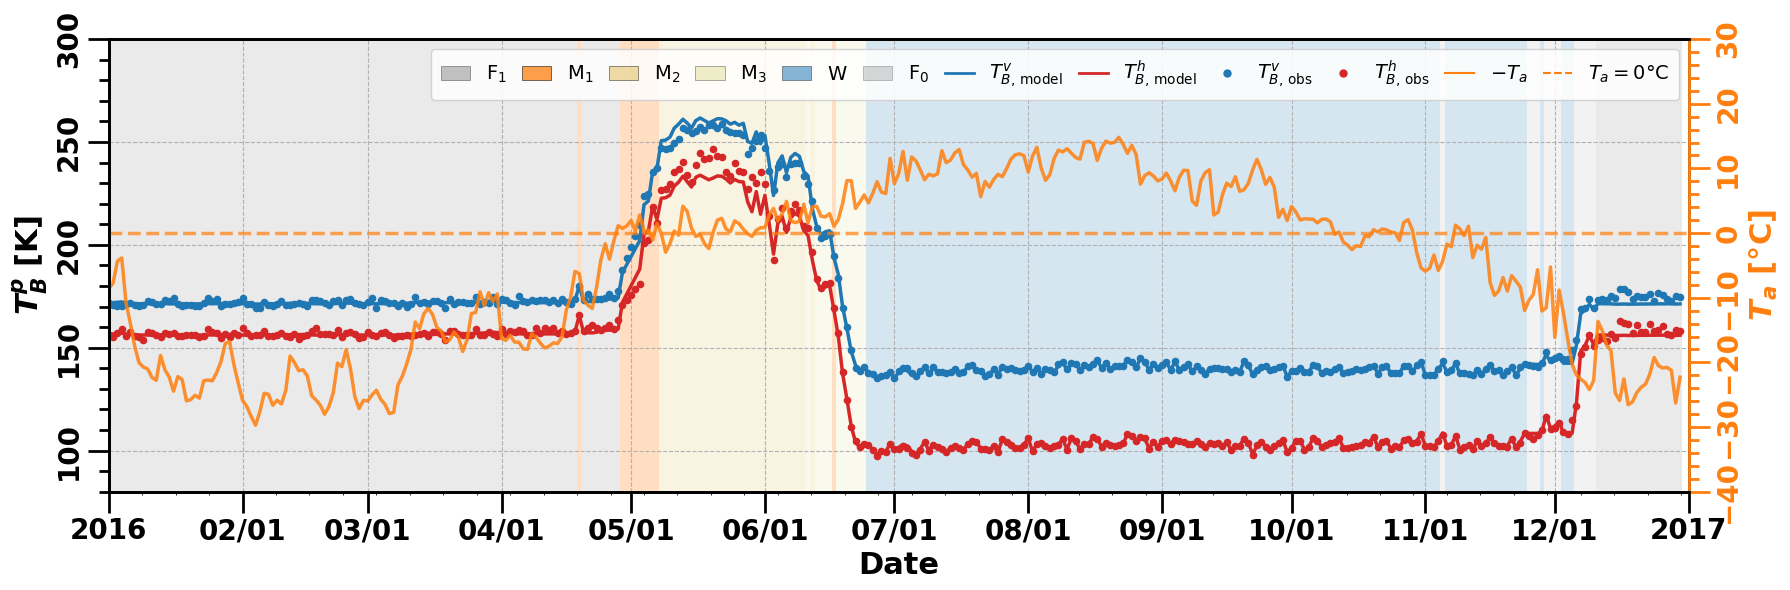

In [43]:
"""
plot_tb_prediction
=====================
Visualization of Annual Lake Ice TB Prediction

Plots predicted and observed dual-polarization TBs alongside ERA5 air
temperature, with ice phenology state shown as color-coded background shading.
"""



# ---------------------------------------------------------------------------
# State metadata
# ---------------------------------------------------------------------------
CLASS_COLORS = {
    1: "gray",      # F1 — Frozen
    2: "#FF7F0E",   # M1 — Melt hump
    3: "#E4C46D",   # M2 — Plateau
    4: "#DBDB8D",   # M3 — Sharp decline
    5: "#1F77B4",   # W  — Open water
    6: "gray",      # F0 — Freeze-up
}
CLASS_ALPHAS = {1: 0.16, 2: 0.25, 3: 0.20, 4: 0.15, 5: 0.18, 6: 0.10}
CLASS_LABELS = {
    1: r'$\mathregular{F_1}$',
    2: r'$\mathregular{M_1}$',
    3: r'$\mathregular{M_2}$',
    4: r'$\mathregular{M_3}$',
    5: r'$\mathregular{W}$',
    6: r'$\mathregular{F_0}$',
}

TB_YLIM = [80,  300]   # Fixed TB y-axis range (K)
TA_YLIM = [-40,  30]   # Fixed Ta y-axis range (°C)
lw = 2.5


def plot_tb_prediction(results, tbh_obs, tbv_obs, t2m,
                       start_date=datetime.date(2016, 1, 1),
                       window=5, figsize=(18, 6),
                       fz=20, ticklength=15, spwid=2):
    """
    Plot predicted and observed dual-polarization TBs with ice state
    background shading and ERA5 air temperature on a twin y-axis.

    Parameters
    ----------
    results    : dict         Output of predict_annual_tb(); must contain
                              'tbh_pred', 'tbv_pred', 'classes'.
    tbh_obs    : array-like   Full observed TBh time series (K).
    tbv_obs    : array-like   Full observed TBv time series (K).
    t2m        : array-like   Full ERA5 2m air temperature time series (K).
    start_date : date         Calendar date corresponding to index 0 of the
                              prediction arrays (default: Jan 1 2016).
    window     : int          Sliding window used during prediction (default: 5).
    figsize    : tuple        Figure size (default: (18, 6)).
    fz         : int          Base font size (default: 20).
    ticklength : int          Major tick length in points (default: 15).
    spwid      : int          Spine and tick linewidth (default: 2).

    Returns
    -------
    fig, ax, ax_ta : matplotlib Figure and Axes objects.
    """
    tbh_pred = results['tbh_pred']
    tbv_pred = results['tbv_pred']
    classes  = results['classes']
    n_pred   = len(tbh_pred)

    # Build date axis — one date per predicted timestep
    # datetime.datetime required (not date) so that sub-day timedelta arithmetic works
    t0 = datetime.datetime(start_date.year, start_date.month, start_date.day)
    dates = [t0 + datetime.timedelta(days=i) for i in range(n_pred)]

    # Align observations and temperature to the prediction window
    tbh_plot = np.array(tbh_obs[window - 1 : window - 1 + n_pred])
    tbv_plot = np.array(tbv_obs[window - 1 : window - 1 + n_pred])
    ta_plot  = np.array(t2m[window - 1 : window - 1 + n_pred]) - 273.15

    # -----------------------------------------------------------------------
    # Figure layout
    # -----------------------------------------------------------------------
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax_ta   = ax.twinx()

    # -----------------------------------------------------------------------
    # Background shading — one axvspan per day, centered on that day
    # -----------------------------------------------------------------------
    half = datetime.timedelta(hours=12)
    for i, cls in enumerate(classes):
        ax.axvspan(dates[i] - half, dates[i] + half,
                   color=CLASS_COLORS[cls],
                   alpha=CLASS_ALPHAS[cls],
                   linewidth=0)

    # -----------------------------------------------------------------------
    # Air temperature (right axis)
    # -----------------------------------------------------------------------
    ax_ta.plot(dates, ta_plot, color='tab:orange', linewidth=lw,
               alpha=0.85, zorder=1)
    ax_ta.axhline(0, color='tab:orange', linewidth=lw,
                  linestyle='--', alpha=0.7, zorder=1)
    ax_ta.set_ylim(TA_YLIM)
    ax_ta.set_ylabel(r'$\mathbfit{T_a}$ [°C]', fontsize=fz * 1.1,
                     fontweight='bold', color='tab:orange')

    # -----------------------------------------------------------------------
    # Observed TBs (scatter)
    # -----------------------------------------------------------------------
    ax.scatter(dates, tbh_plot, s=20, color='#D62728', zorder=2)
    ax.scatter(dates, tbv_plot, s=20, color='#1F77B4', zorder=2)

    # -----------------------------------------------------------------------
    # Predicted TBs (lines)
    # -----------------------------------------------------------------------
    ax.plot(dates, tbh_pred, color='#D62728', linewidth=lw, zorder=3)
    ax.plot(dates, tbv_pred, color='#1F77B4', linewidth=lw, zorder=3)

    # -----------------------------------------------------------------------
    # Axes limits and labels
    # -----------------------------------------------------------------------
    ax.set_ylim(TB_YLIM)
    ax.set_xlim(dates[0], datetime.datetime(t0.year + 1, 1, 1))
    ax.set_ylabel(r'$\mathbfit{T^p_B}$ [K]', fontsize=fz * 1.1, fontweight='bold')
    ax.set_xlabel('Date',          fontsize=fz * 1.1, fontweight='bold')

    ax.xaxis.set_major_locator(mdates.MonthLocator())

    def _date_formatter(x, pos):
        d = mdates.num2date(x)
        if d.month == 1 and d.day == 1:
            return str(d.year)
        return d.strftime('%m/%d')

    ax.xaxis.set_major_formatter(plt.FuncFormatter(_date_formatter))

    # -----------------------------------------------------------------------
    # Styling — main axis
    # -----------------------------------------------------------------------
    ax.grid(True, axis='both', linestyle='--', alpha=1)

    for spine in ax.spines.values():
        spine.set_linewidth(spwid)
        spine.set_edgecolor('black')

    ax.tick_params(axis='both', which='major',
                   length=ticklength, width=spwid,
                   labelsize=fz, color='black')
    ax.tick_params(axis='y', which='minor',
                   length=ticklength / 2, width=spwid,
                   labelbottom=False, labelleft=False)
    ax.minorticks_on()

    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')
    for label in ax.get_yticklabels():
        label.set_rotation(90)
        label.set_verticalalignment('center')
        label.set_horizontalalignment('right')

    # -----------------------------------------------------------------------
    # Styling — twin axis (Ta)
    # -----------------------------------------------------------------------
    ax_ta.spines['right'].set_linewidth(spwid)
    ax_ta.spines['right'].set_edgecolor('tab:orange')
    for side in ['left', 'top', 'bottom']:
        ax_ta.spines[side].set_linewidth(spwid)
        ax_ta.spines[side].set_edgecolor('black')

    ax_ta.tick_params(axis='y', which='major',
                      length=ticklength, width=spwid,
                      labelsize=fz, color='tab:orange', labelcolor='tab:orange')
    ax_ta.tick_params(axis='y', which='minor',
                      length=ticklength / 2, width=spwid,
                      color='tab:orange',
                      labelbottom=False, labelleft=False)
    ax_ta.minorticks_on()

    for label in ax_ta.get_yticklabels():
        label.set_fontweight('bold')
        label.set_rotation(90)
        label.set_verticalalignment('center')
        label.set_color('tab:orange')

    # -----------------------------------------------------------------------
    # Legend
    # -----------------------------------------------------------------------
    class_patches = [
        mpatches.Patch(facecolor=CLASS_COLORS[c],
                       alpha=min(CLASS_ALPHAS[c] * 3, 1.0),
                       edgecolor='black', linewidth=0.5,
                       label=CLASS_LABELS[c])
        for c in sorted(CLASS_COLORS)
    ]

    line_handles = [
        mlines.Line2D([], [], color='#1F77B4', linewidth=2,
                      label=r'$T^v_{B,\,\mathrm{model}}$'),
        mlines.Line2D([], [], color='#D62728', linewidth=2,
                      label=r'$T^h_{B,\,\mathrm{model}}$'),
        mlines.Line2D([], [], color='#1F77B4', linewidth=0,
                      marker='o', markersize=5,
                      label=r'$T^v_{B,\,\mathrm{obs}}$'),
        mlines.Line2D([], [], color='#D62728', linewidth=0,
                      marker='o', markersize=5,
                      label=r'$T^h_{B,\,\mathrm{obs}}$'),
        mlines.Line2D([], [], color='tab:orange', linewidth=1.5,
                      label=r'$-T_a$'),
        mlines.Line2D([], [], color='tab:orange', linewidth=1.5,
                      linestyle='--', label=r'$T_a=0\rm{°C}$'),
    ]

    ax.legend(handles=class_patches + line_handles,
              loc='upper right', fontsize=fz * 0.7,
              framealpha=0.85,
              ncol=len(class_patches) + len(line_handles),
              handlelength=1.5, borderpad=0.5, columnspacing=0.8)

    plt.tight_layout()
    plt.show()
    return fig, ax, ax_ta
    
fig, ax, ax_ta = plot_tb_prediction(results, tbh, tbv, t2m,
                       start_date=datetime.date(2016, 1, 1),
                       window=5, figsize=(18, 6),
                       fz=20, ticklength=15, spwid=2)